# NLP Preprocessing, Modeling, and Evaluation Comparison
### Academic Framework for Fake News Detection with Entity Masking, Feature Importance, and SHAP Interpretability

This notebook implements a complete modeling and evaluation pipeline for fake news classification using the ISOT Fake News Dataset. It is structured into **10 sections** to support a comparative study:
- **Entity Masking at Source**: Replacing all named entities (e.g. `[PERSON]`, `[ORG]`, `[GPE]`, etc.) before cleaning.
- **Top 5 Feature Importance**: Training a Random Forest to extract and plot the top 5 most important engineered features (linguistic, sentiment, POS/NER counts).
- **SHAP Interpretability**: Utilizing SHAP (SHapley Additive exPlanations) values to explain the Random Forest model's decisions on the engineered features.
- **Comparative Architectures**: Evaluating 27 configurations across Rule-based, Logistic Regression, Linear SVM, Naïve Bayes, Random Forest, Deep Learning, and Transformers (BERT) both **with** and **without** the top 5 engineered features using BoW, TF-IDF, Word2Vec, and Transformers representations.
- **Evaluation and Visualizations**: Generating a single consolidated score comparison table of all 27 configurations, **7 separate score bar plots** with text values inside the bars, and **4 separate confusion matrix blocks**.


## 1 & 2. Dataset Loading, Cleaning, Sampling, and Exploration
We load `True.csv` and `Fake.csv`, clean text columns, deduplicate, and split the data:
- **Training Set**: 7,500 balanced samples (3,750 Real, 3,750 Fake).
- **Testing Set**: 1,500 balanced samples (750 Real, 750 Fake).
- **Exploration**: Verify and plot that the 1,500 test set articles contain different sentence lengths.


Deduplicated dataset size: 38646
Selected dataset size: 7500

Class distribution:
label
0    3750
1    3750
Name: count, dtype: int64

Training set: 6000 samples
Testing set: 1500 samples

Training class distribution:
label
0    3000
1    3000
Name: count, dtype: int64

Testing class distribution:
label
0    750
1    750
Name: count, dtype: int64


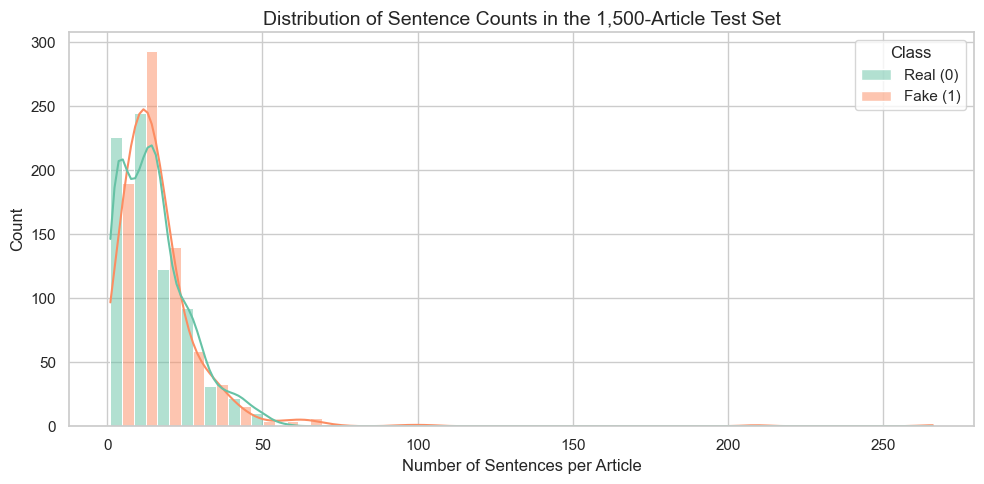

In [48]:
import pandas as pd
import numpy as np
import re
import string
import os
import pickle
import json
import nltk

from nltk.tokenize import sent_tokenize, word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


# =========================================================
# 1. LOAD DATASETS
# =========================================================

true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')


# =========================================================
# 2. ASSIGN TARGET LABELS
# =========================================================

# Real = 0
# Fake = 1

true_df['label'] = 0
fake_df['label'] = 1


# =========================================================
# 3. COMBINE DATASETS
# =========================================================

df_full = pd.concat(
    [true_df, fake_df],
    ignore_index=True
)


# =========================================================
# 4. REMOVE MISSING VALUES AND DUPLICATES
# =========================================================

df_full = (
    df_full
    .dropna(subset=['text'])
    .drop_duplicates(subset=['text'])
    .reset_index(drop=True)
)

df_full['title'] = df_full['title'].fillna('')


# Combine title and article text

df_full['document'] = (
    df_full['title'] + ' ' + df_full['text']
).str.strip()


# Remove empty documents

df_full = df_full[
    df_full['document'] != ''
].reset_index(drop=True)


print(
    f"Deduplicated dataset size: {df_full.shape[0]}"
)


# =========================================================
# 5. CREATE BALANCED 7,500-ARTICLE DATASET
# =========================================================

# Select 3,750 real and 3,750 fake articles

real_sample = (
    df_full[df_full['label'] == 0]
    .sample(
        n=3750,
        random_state=RANDOM_STATE
    )
)

fake_sample = (
    df_full[df_full['label'] == 1]
    .sample(
        n=3750,
        random_state=RANDOM_STATE
    )
)


# Combine the two classes

df_sample = pd.concat(
    [real_sample, fake_sample],
    ignore_index=True
)


# Shuffle the complete 7,500 observations

df_sample = (
    df_sample
    .sample(
        frac=1.0,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)


print(
    f"Selected dataset size: {df_sample.shape[0]}"
)

print(
    "\nClass distribution:"
)

print(
    df_sample['label'].value_counts()
)


# =========================================================
# 6. STRATIFIED 80:20 TRAIN-TEST SPLIT
# =========================================================

train_df, test_df = train_test_split(
    df_sample,
    test_size=0.20,
    train_size=0.80,
    random_state=RANDOM_STATE,
    stratify=df_sample['label']
)


# Reset indices

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# =========================================================
# 7. DISPLAY SPLIT INFORMATION
# =========================================================

print(
    f"\nTraining set: "
    f"{train_df.shape[0]} samples"
)

print(
    f"Testing set: "
    f"{test_df.shape[0]} samples"
)


print(
    "\nTraining class distribution:"
)

print(
    train_df['label'].value_counts()
)


print(
    "\nTesting class distribution:"
)

print(
    test_df['label'].value_counts()
)


# =========================================================
# 8. SENTENCE COUNT FOR TEST SET
# =========================================================

nltk.download(
    'punkt',
    quiet=True
)

test_df['sentence_count'] = test_df[
    'document'
].apply(
    lambda x:
    len(sent_tokenize(x))
    if isinstance(x, str)
    else 0
)


test_df['Class'] = test_df[
    'label'
].map({
    0: 'Real (0)',
    1: 'Fake (1)'
})


# =========================================================
# 9. VISUALISE SENTENCE DISTRIBUTION
# =========================================================

plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    data=test_df,
    x='sentence_count',
    hue='Class',
    kde=True,
    bins=35,
    palette='Set2',
    multiple='dodge'
)

plt.title(
    'Distribution of Sentence Counts in the 1,500-Article Test Set',
    fontsize=14
)

plt.xlabel(
    'Number of Sentences per Article',
    fontsize=12
)

plt.ylabel(
    'Count',
    fontsize=12
)

plt.tight_layout()

plt.show()

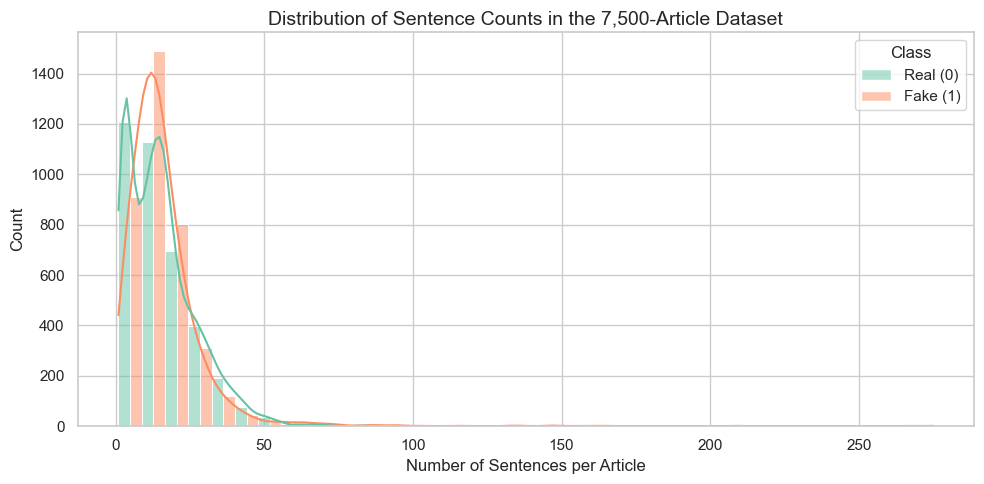

In [49]:
# =========================================================
# 8. SENTENCE COUNT FOR OVERALL 7,500-ARTICLE DATASET
# =========================================================

nltk.download('punkt', quiet=True)

df_sample['sentence_count'] = df_sample['document'].apply(
    lambda x: len(sent_tokenize(x))
    if isinstance(x, str)
    else 0
)

df_sample['Class'] = df_sample['label'].map({
    0: 'Real (0)',
    1: 'Fake (1)'
})


# =========================================================
# 9. VISUALISE SENTENCE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_sample,
    x='sentence_count',
    hue='Class',
    kde=True,
    bins=35,
    palette='Set2',
    multiple='dodge'
)

plt.title(
    'Distribution of Sentence Counts in the 7,500-Article Dataset',
    fontsize=14
)

plt.xlabel(
    'Number of Sentences per Article',
    fontsize=12
)

plt.ylabel(
    'Count',
    fontsize=12
)

plt.tight_layout()
plt.show()

In [50]:
# =========================================================
# DESCRIPTIVE STATISTICS OF WORD COUNTS
# =========================================================

# Calculate word count for each article
df_sample['word_count'] = df_sample['document'].apply(
    lambda x: len(str(x).split())
)

# Descriptive statistics by class
word_stats = df_sample.groupby(
    df_sample['label'].map({
        0: 'Real',
        1: 'Fake'
    })
)['word_count'].describe()

# Keep the required statistics
word_stats = word_stats[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

print("\n=== Descriptive Statistics of Word Counts ===")
print(word_stats.round(2))


=== Descriptive Statistics of Word Counts ===
        count    mean     std   min    25%    50%    75%     max
label                                                           
Fake   3750.0  446.41  369.00   2.0  294.0  394.0  522.0  7042.0
Real   3750.0  390.90  266.05  34.0  148.0  364.0  537.0  1686.0


## 3. Named Entity Masking
To prevent downstream models from memorizing specific entity names, we locate all named entities in the raw text and replace them with generic tokens (e.g. `[PERSON]`, `[ORG]`, `[GPE]`, `[DATE]`, `[CARDINAL]`).
We use `spaCy`'s `en_core_web_sm` model directly.


In [51]:
import spacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

def mask_entities(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    doc = nlp(text[:15000])
    ents = sorted(doc.ents, key=lambda e: e.start_char, reverse=True)
    text_list = list(text)
    for ent in ents:
        text_list[ent.start_char:ent.end_char] = list(f"[{ent.label_}]")
    return ''.join(text_list)

print("Applying Named Entity Masking to train and test sets...")
train_df['document'] = train_df['document'].apply(mask_entities)
test_df['document'] = test_df['document'].apply(mask_entities)
print("Sample masked document text:")
print(train_df['document'].iloc[0][:250])

Applying Named Entity Masking to train and test sets...
Sample masked document text:
[GPE]'s military muscles into [ORDINAL] [NORP] cabinet [PERSON] ([ORG]) - Zimbabwe President [PERSON] appointed senior military officials to top posts in his [ORDINAL] cabinet on [DATE] in what was widely seen as a reward for the army s role in the r


## 4 & 5. Preprocessing Pipelines & Feature Engineering
We run cleaning pipelines A, B, and C on the masked text. We then extract **30 handcrafted features** covering linguistic characteristics, VADER sentiment polarity, and POS/NER tag frequencies (calculated directly from the entity tags in the masked text).


In [52]:
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

CONTRACTION_MAP = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "could've": "could have", "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is", "i'd": "i would",
    "i'll": "i will", "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'll": "it will", "it's": "it is", "let's": "let us", "might've": "might have",
    "mightn't": "might not", "must've": "must have", "mustn't": "must not", "needn't": "need not",
    "shan't": "shall not", "she'd": "she would", "she'll": "she will", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "that's": "that is", "there's": "there is",
    "they'd": "they would", "they'll": "they will", "they're": "they are", "they've": "they have",
    "wasn't": "was not", "we'd": "we would", "we'll": "we will", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "would've": "would have", "wouldn't": "would not",
    "you'd": "you would", "you'll": "you will", "you're": "you are", "you've": "you have"
}

def expand_contractions(text, contraction_mapping=CONTRACTION_MAP):
    contractions_pattern = re.compile('({})'.format('|'.join(contraction_mapping.keys())), 
                                      flags=re.IGNORECASE|re.DOTALL)
    def expand_match(contraction):
        match = contraction.group(0)
        first_char = match[0]
        expanded_contraction = contraction_mapping.get(match) \
            if contraction_mapping.get(match) \
            else contraction_mapping.get(match.lower())
        if not expanded_contraction:
            return match
        expanded_contraction = first_char + expanded_contraction[1:]
        return expanded_contraction
    return contractions_pattern.sub(expand_match, text)

def clean_isolated_numbers(text):
    def replace_num(match):
        val = match.group(0)
        if len(val) == 4 and val.isdigit() and 1800 <= int(val) <= 2100:
            return val
        return ""
    return re.sub(r'\b\d+\b', replace_num, text)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_pipeline_a(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    text = expand_contractions(text)
    text = clean_isolated_numbers(text)
    text = re.sub(r'([!?.])\1+', r'\1', text)
    tokens = word_tokenize(text)
    table = str.maketrans('', '', string.punctuation)
    stripped = [w.translate(table) for w in tokens]
    cleaned_tokens = []
    for w in stripped:
        if w.isalpha() and w not in stop_words and len(w) > 1:
            cleaned_tokens.append(lemmatizer.lemmatize(w, pos='v'))
    return " ".join(cleaned_tokens)

def preprocess_pipeline_b(text):
    if not isinstance(text, str):
        return []
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return tokens

def preprocess_pipeline_c(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Running text cleaning pipelines...")
train_df['doc_pipeline_a'] = train_df['document'].apply(preprocess_pipeline_a)
test_df['doc_pipeline_a'] = test_df['document'].apply(preprocess_pipeline_a)
train_df['tokens_pipeline_b'] = train_df['document'].apply(preprocess_pipeline_b)
test_df['tokens_pipeline_b'] = test_df['document'].apply(preprocess_pipeline_b)
train_df['doc_pipeline_c'] = train_df['document'].apply(preprocess_pipeline_c)
test_df['doc_pipeline_c'] = test_df['document'].apply(preprocess_pipeline_c)

# Handcrafted features extraction
CLICKBAIT_TERMS = ['breaking', 'shocking', "won't believe", "wont believe", 'secret', 'revealed', 'mind-blowing', 'mind blowing', 'incredible', 'miraculous', 'unbelievable', 'sensational', 'exposed', 'must watch', 'must-see', 'will blow your mind', 'shocked', 'conspiracy', 'insane', 'lost words', 'wtf']
FIRST_PERSON_PRONOUNS = {'i', 'me', 'my', 'myself', 'we', 'us', 'our', 'ours', 'ourselves'}

def count_syllables(word):
    word = word.lower()
    if len(word) <= 3: return 1
    count = 0
    vowels = "aeiouy"
    if word[0] in vowels: count += 1
    for index in range(1, len(word)):
        if word[index] in vowels and word[index - 1] not in vowels: count += 1
    if word.endswith("e"): count -= 1
    if word.endswith("le") and len(word) > 2 and word[-3] not in vowels: count += 1
    return max(1, count)

def extract_features(text):
    features = {}
    cleaned_text = re.sub(r'\s+', ' ', text).strip()
    features['doc_char_length'] = len(cleaned_text)
    features['exclamation_count'] = cleaned_text.count('!')
    features['question_count'] = cleaned_text.count('?')
    features['quote_count'] = cleaned_text.count('"') + cleaned_text.count("'")
    
    sentences = sent_tokenize(cleaned_text)
    num_sentences = max(len(sentences), 1)
    words = word_tokenize(cleaned_text)
    words_alpha = [w.lower() for w in words if w.isalnum()]
    num_words = max(len(words_alpha), 1)
    
    features['avg_sentence_len'] = num_words / num_sentences
    features['avg_word_len'] = sum(len(w) for w in words_alpha) / num_words
    features['vocab_richness'] = len(set(words_alpha)) / num_words
    features['uppercase_word_count'] = len([w for w in words if w.isupper() and w.isalpha() and len(w) > 1])
    features['capital_letter_ratio'] = sum(1 for c in cleaned_text if c.isupper()) / max(len(cleaned_text), 1)
    features['first_person_pronouns_count'] = sum(1 for w in words_alpha if w in FIRST_PERSON_PRONOUNS)
    
    clickbait_count = 0
    text_lower = cleaned_text.lower()
    for term in CLICKBAIT_TERMS:
        clickbait_count += len(re.findall(r'\b' + re.escape(term) + r'\b', text_lower))
    features['sensational_word_count'] = clickbait_count
    
    syllables = [count_syllables(w) for w in words_alpha]
    total_syllables = sum(syllables)
    complex_words = sum(1 for s in syllables if s >= 3)
    asl = num_words / num_sentences
    asw = total_syllables / num_words
    pct_complex = (complex_words / num_words) * 100
    
    features['flesch_reading_ease'] = 206.835 - 1.015 * asl - 84.6 * asw
    features['flesch_kincaid_grade'] = 0.39 * asl + 11.8 * asw - 15.59
    features['gunning_fog'] = 0.4 * (asl + pct_complex)
    features['smog_index'] = 1.0430 * ((complex_words * 30 / num_sentences) ** 0.5) + 3.1291
    features['automated_readability_index'] = 4.71 * (sum(len(w) for w in words_alpha) / num_words) + 0.5 * asl - 21.43
    
    return features

print("Engineering linguistic features...")
train_ling_df = pd.DataFrame([extract_features(doc) for doc in train_df['document']])
test_ling_df = pd.DataFrame([extract_features(doc) for doc in test_df['document']])

from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
def extract_sentiment(text):
    scores = sia.polarity_scores(text)
    return {'sentiment_pos': scores['pos'], 'sentiment_neg': scores['neg'], 'sentiment_neu': scores['neu'], 'sentiment_compound': scores['compound']}
train_sent_df = pd.DataFrame([extract_sentiment(doc) for doc in train_df['document']])
test_sent_df = pd.DataFrame([extract_sentiment(doc) for doc in test_df['document']])

def extract_pos_ner_counts(text):
    pos_counts = {'noun_count': 0, 'verb_count': 0, 'adj_count': 0, 'adv_count': 0}
    doc = nlp(text[:15000])
    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN'): pos_counts['noun_count'] += 1
        elif token.pos_ in ('VERB', 'AUX'): pos_counts['verb_count'] += 1
        elif token.pos_ == 'ADJ': pos_counts['adj_count'] += 1
        elif token.pos_ == 'ADV': pos_counts['adv_count'] += 1
    # Passive voice count
    be_forms = {'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being'}
    passive_voice_count = 0
    for token in doc:
        if token.tag_ == 'VBN':
            for child in token.children:
                if child.dep_ in ('aux', 'auxpass') and child.text.lower() in be_forms:
                    passive_voice_count += 1
                    break
                            
    ner_counts = {
        'ent_person': text.count('[PERSON]'),
        'ent_org': text.count('[ORG]'),
        'ent_gpe': text.count('[GPE]'),
        'ent_date': text.count('[DATE]'),
        'ent_cardinal': text.count('[CARDINAL]')
    }
    res = {}
    res.update(pos_counts)
    res.update(ner_counts)
    res['passive_voice_count'] = passive_voice_count
    return res

print("Extracting POS & NER tag frequencies from masked text...")
train_pos_ner_df = pd.DataFrame([extract_pos_ner_counts(doc) for doc in train_df['document']])
test_pos_ner_df = pd.DataFrame([extract_pos_ner_counts(doc) for doc in test_df['document']])

train_ling_df['passive_voice_count'] = train_pos_ner_df['passive_voice_count']
test_ling_df['passive_voice_count'] = test_pos_ner_df['passive_voice_count']
train_pos_ner_df = train_pos_ner_df.drop(columns=['passive_voice_count'])
test_pos_ner_df = test_pos_ner_df.drop(columns=['passive_voice_count'])

# Combine all features
train_features = pd.concat([train_ling_df, train_sent_df, train_pos_ner_df], axis=1)
test_features = pd.concat([test_ling_df, test_sent_df, test_pos_ner_df], axis=1)
print(f"Consolidated engineered feature dimensions: {train_features.shape}")


Running text cleaning pipelines...
Engineering linguistic features...
Extracting POS & NER tag frequencies from masked text...
Consolidated engineered feature dimensions: (6000, 30)


## 6. Feature Importance and SHAP Interpretability Analysis
We train a Random Forest classifier on the engineered features and extract the Gini importances. We then select and plot the **top 5** most important features.
We then use **SHAP (SHapley Additive exPlanations)** values via `shap.TreeExplainer` directly to interpret the Random Forest model and generate a summary dot plot.


Top 5 most important engineered features: ['question_count', 'adv_count', 'ent_gpe', 'exclamation_count', 'ent_date']


C:\Users\tarun\AppData\Local\Temp\ipykernel_7624\3191318715.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.head(10).values, y=feat_importances.head(10).index, palette='crest')


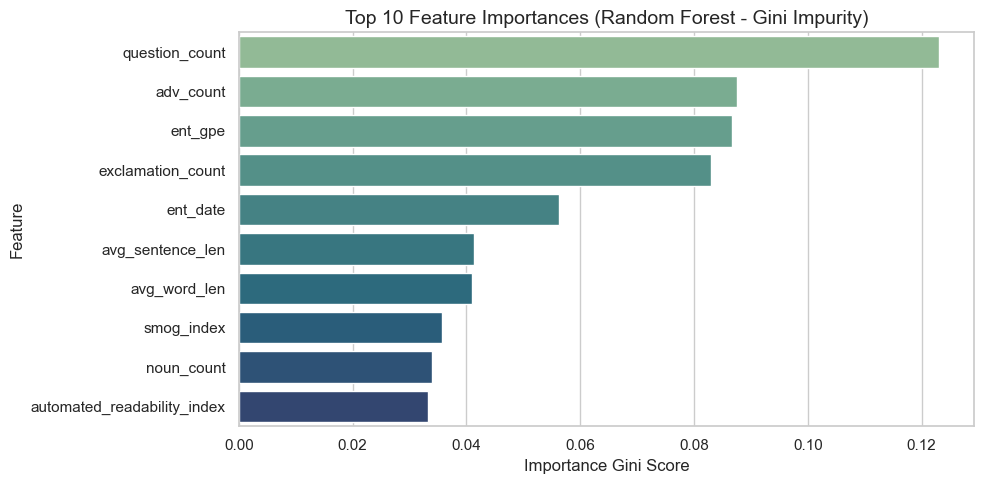

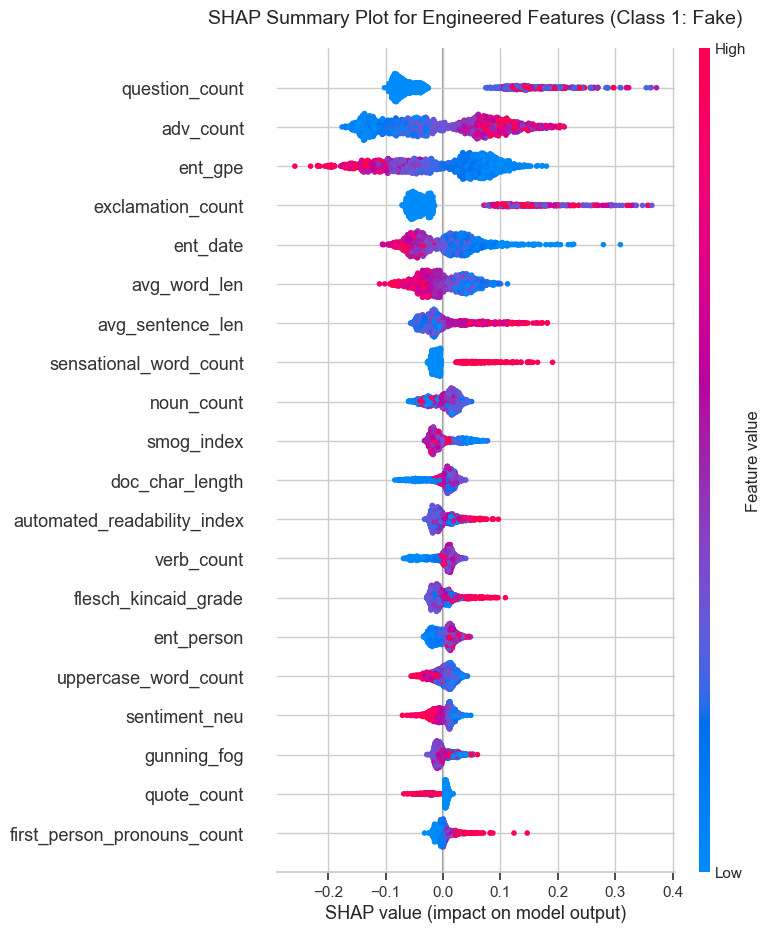

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import shap

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)

train_scaled_df = pd.DataFrame(X_train_scaled, columns=train_features.columns)
test_scaled_df = pd.DataFrame(X_test_scaled, columns=test_features.columns)

rf_feat_importance = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_feat_importance.fit(train_scaled_df, train_df['label'])

importances = rf_feat_importance.feature_importances_
feat_importances = pd.Series(importances, index=train_features.columns).sort_values(ascending=False)

top_5_features = feat_importances.head(5).index.tolist()
print("Top 5 most important engineered features:", top_5_features)

# Plot Gini Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_importances.head(10).values, y=feat_importances.head(10).index, palette='crest')
plt.title('Top 10 Feature Importances (Random Forest - Gini Impurity)', fontsize=14)
plt.xlabel('Importance Gini Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(rf_feat_importance)
shap_values = explainer.shap_values(test_scaled_df)

# Handle version differences in SHAP outputs
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_to_plot = shap_values[:, :, 1]
else:
    shap_vals_to_plot = shap_values
    
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, test_scaled_df, show=False)
plt.title('SHAP Summary Plot for Engineered Features (Class 1: Fake)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Scaled splits containing ONLY the top 5 features (StandardScaler for RF/LR/SVM)
train_top_feats = train_scaled_df[top_5_features].values
test_top_feats = test_scaled_df[top_5_features].values

# MinMaxScaler top 5 features (for Naive Bayes non-negativity constraint)
minmax_scaler = MinMaxScaler()
train_top_feats_nb = minmax_scaler.fit_transform(train_features[top_5_features])
test_top_feats_nb = minmax_scaler.transform(test_features[top_5_features])


## 7. Vectorization Setups and Word2Vec Model Training
We set up three text vectorization representations:
1. **TF-IDF & Chi-Square selection**: TF-IDF fit on Pipeline A train text with `min_df=2`, `max_df=0.95`, and N-grams (1,2). We select the top 1,000 features via Chi-Square feature selection.
2. **Word2Vec Sequence Indexing**: Train a `gensim.models.Word2Vec` model directly on the training tokens, map words to vocabulary indexes, construct an embedding matrix, and pad inputs to sequence length 300.
3. **Transformers (BERT Tokenizer)**: Encode Pipeline C texts using `BertTokenizer` to extract input IDs and attention masks (max length 128).


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from gensim.models import Word2Vec
from transformers import BertTokenizer

# A. TF-IDF & Chi-Square Selection
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_tfidf_raw = tfidf.fit_transform(train_df['doc_pipeline_a'])
X_test_tfidf_raw = tfidf.transform(test_df['doc_pipeline_a'])

chi_select = SelectKBest(score_func=chi2, k=1000)
X_train_tfidf = chi_select.fit_transform(X_train_tfidf_raw, train_df['label'])
X_test_tfidf = chi_select.transform(X_test_tfidf_raw)
print(f"Selected TF-IDF shape: {X_train_tfidf.shape}")

# B. Word2Vec Model training (Gensim)
print("Training Word2Vec model on training tokens...")
w2v_model = Word2Vec(sentences=train_df['tokens_pipeline_b'], vector_size=100, window=5, min_count=2, workers=4, seed=RANDOM_STATE)

word_to_idx = {word: idx + 1 for idx, word in enumerate(w2v_model.wv.index_to_key)}
word_to_idx['<PAD>'] = 0
embedding_dim = 100
loaded_embeddings = True
embedding_source_used = "gensim.models.Word2Vec (Trained on Dataset)"

embedding_matrix = np.zeros((len(word_to_idx), 100))
for word, idx in word_to_idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

def pad_sequences(token_lists, word_map, max_len=300):
    sequences = []
    for tokens in token_lists:
        seq = [word_map[token] for token in tokens if token in word_map]
        if len(seq) > max_len: seq = seq[:max_len]
        else: seq = seq + [0] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences)

X_train_w2v = pad_sequences(train_df['tokens_pipeline_b'], word_to_idx)
X_test_w2v = pad_sequences(test_df['tokens_pipeline_b'], word_to_idx)
print(f"Word2Vec padded training shape: {X_train_w2v.shape}")

# C. Transformers Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenize_bert(texts):
    encodings = tokenizer(list(texts), truncation=True, padding='max_length', max_length=128, return_tensors='np')
    return encodings['input_ids'], encodings['attention_mask']
X_train_bert_ids, X_train_bert_masks = tokenize_bert(train_df['doc_pipeline_c'])
X_test_bert_ids, X_test_bert_masks = tokenize_bert(test_df['doc_pipeline_c'])
print("BERT tokenization mapping complete.")


Selected TF-IDF shape: (6000, 1000)
Training Word2Vec model on training tokens...
Word2Vec padded training shape: (6000, 300)
BERT tokenization mapping complete.


## 8. Model Training & Comparison
We train 6 model architectures (Logistic Regression, Linear SVM, Multinomial Naïve Bayes, Random Forest, Deep Learning NN, Transformers BERT), each evaluated **with** and **without** the top 5 engineered features across different representations (BoW, TF-IDF, Word2Vec, BERT) making a total of **26 configurations** plus the Rule-based baseline, totaling **27 configurations**.


In [ ]:
# =========================================================
# IMPORTS AND DEVICE
# =========================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score
)

from transformers import BertModel

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"Using device: {device}")


# =========================================================
# 1. BAG-OF-WORDS (BoW)
# =========================================================

print("\nCreating Bag-of-Words representation...")

train_df['clean_text'] = train_df['doc_pipeline_a']
test_df['clean_text'] = test_df['doc_pipeline_a']

bow_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_bow = bow_vectorizer.fit_transform(
    train_df['clean_text']
)

X_test_bow = bow_vectorizer.transform(
    test_df['clean_text']
)

X_train_bow_arr = X_train_bow.toarray()
X_test_bow_arr = X_test_bow.toarray()


# BoW + engineered features

X_train_bow_feats = np.hstack(
    (X_train_bow_arr, train_top_feats)
)

X_test_bow_feats = np.hstack(
    (X_test_bow_arr, test_top_feats)
)


# BoW + NB-compatible engineered features

X_train_bow_nb = np.hstack(
    (X_train_bow_arr, train_top_feats_nb)
)

X_test_bow_nb = np.hstack(
    (X_test_bow_arr, test_top_feats_nb)
)

print("BoW Train Shape:", X_train_bow_arr.shape)
print("BoW Test Shape:", X_test_bow_arr.shape)


# =========================================================
# 2. TF-IDF
# =========================================================

X_train_tfidf_arr = X_train_tfidf.toarray()
X_test_tfidf_arr = X_test_tfidf.toarray()


# TF-IDF + engineered features

X_train_tfidf_feats = np.hstack(
    (X_train_tfidf_arr, train_top_feats)
)

X_test_tfidf_feats = np.hstack(
    (X_test_tfidf_arr, test_top_feats)
)


# TF-IDF + NB-compatible engineered features

X_train_tfidf_nb = np.hstack(
    (X_train_tfidf_arr, train_top_feats_nb)
)

X_test_tfidf_nb = np.hstack(
    (X_test_tfidf_arr, test_top_feats_nb)
)


# =========================================================
# 3. LOGISTIC REGRESSION
# =========================================================

print("\nTraining Logistic Regression (BoW)...")

lr_bow_without = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_bow_without.fit(
    X_train_bow_arr,
    train_df['label']
)

lr_bow_with = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_bow_with.fit(
    X_train_bow_feats,
    train_df['label']
)

preds_lr_bow_without = lr_bow_without.predict(
    X_test_bow_arr
)

preds_lr_bow_with = lr_bow_with.predict(
    X_test_bow_feats
)


print("\nTraining Logistic Regression (TF-IDF)...")

lr_without = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_without.fit(
    X_train_tfidf_arr,
    train_df['label']
)

lr_with = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_with.fit(
    X_train_tfidf_feats,
    train_df['label']
)


# =========================================================
# WORD2VEC DOCUMENT REPRESENTATIONS
# =========================================================

def get_average_w2v(tokens, w2v_model_obj, dim=100):

    vectors = [
        w2v_model_obj.wv[word]
        for word in tokens
        if word in w2v_model_obj.wv
    ]

    if len(vectors) == 0:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)


X_train_w2v_avg = np.array([
    get_average_w2v(
        t,
        w2v_model,
        dim=100
    )
    for t in train_df['tokens_pipeline_b']
])

X_test_w2v_avg = np.array([
    get_average_w2v(
        t,
        w2v_model,
        dim=100
    )
    for t in test_df['tokens_pipeline_b']
])


# Word2Vec + engineered features

X_train_w2v_feats = np.hstack(
    (X_train_w2v_avg, train_top_feats)
)

X_test_w2v_feats = np.hstack(
    (X_test_w2v_avg, test_top_feats)
)


# =========================================================
# LOGISTIC REGRESSION - WORD2VEC
# =========================================================

print("\nTraining Logistic Regression (Word2Vec)...")

lr_w2v_without = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_w2v_without.fit(
    X_train_w2v_avg,
    train_df['label']
)

lr_w2v_with = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_w2v_with.fit(
    X_train_w2v_feats,
    train_df['label']
)


# =========================================================
# 4. LINEAR SVM
# =========================================================

print("\nTraining SVM (BoW)...")

svm_bow_without = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual='auto'
)

svm_bow_without.fit(
    X_train_bow_arr,
    train_df['label']
)

svm_bow_with = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual='auto'
)

svm_bow_with.fit(
    X_train_bow_feats,
    train_df['label']
)


print("\nTraining SVM (TF-IDF)...")

svm_without = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual='auto'
)

svm_without.fit(
    X_train_tfidf_arr,
    train_df['label']
)

svm_with = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual='auto'
)

svm_with.fit(
    X_train_tfidf_feats,
    train_df['label']
)


print("\nTraining SVM (Word2Vec)...")

svm_w2v_without = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual='auto'
)

svm_w2v_without.fit(
    X_train_w2v_avg,
    train_df['label']
)

svm_w2v_with = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual='auto'
)

svm_w2v_with.fit(
    X_train_w2v_feats,
    train_df['label']
)


# =========================================================
# 5. MULTINOMIAL NAIVE BAYES
# =========================================================

print("\nTraining Naive Bayes (BoW)...")

nb_bow_without = MultinomialNB()

nb_bow_without.fit(
    X_train_bow_arr,
    train_df['label']
)

nb_bow_with = MultinomialNB()

nb_bow_with.fit(
    X_train_bow_nb,
    train_df['label']
)


print("\nTraining Naive Bayes (TF-IDF)...")

nb_without = MultinomialNB()

nb_without.fit(
    X_train_tfidf_arr,
    train_df['label']
)

nb_with = MultinomialNB()

nb_with.fit(
    X_train_tfidf_nb,
    train_df['label']
)


# =========================================================
# 6. RANDOM FOREST
# =========================================================

print("\nTraining Random Forest (BoW)...")

rf_bow_without = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_bow_without.fit(
    X_train_bow_arr,
    train_df['label']
)

rf_bow_with = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_bow_with.fit(
    X_train_bow_feats,
    train_df['label']
)


print("\nTraining Random Forest (TF-IDF)...")

rf_without = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_without.fit(
    X_train_tfidf_arr,
    train_df['label']
)

rf_with = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_with.fit(
    X_train_tfidf_feats,
    train_df['label']
)


print("\nTraining Random Forest (Word2Vec)...")

rf_w2v_without = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_w2v_without.fit(
    X_train_w2v_avg,
    train_df['label']
)

rf_w2v_with = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_w2v_with.fit(
    X_train_w2v_feats,
    train_df['label']
)


# =========================================================
# 7. DEEP LEARNING - PRETRAINED WORD2VEC
# =========================================================

print("\nPreparing pretrained Word2Vec embeddings...")



# ---------------------------------------------------------
# Convert padded token sequences to tensors
# ---------------------------------------------------------

train_w2v_t = torch.tensor(
    X_train_w2v,
    dtype=torch.long
)

test_w2v_t = torch.tensor(
    X_test_w2v,
    dtype=torch.long
)

train_y_t = torch.tensor(
    train_df['label'].values,
    dtype=torch.long
)

test_y_t = torch.tensor(
    test_df['label'].values,
    dtype=torch.long
)

train_feats_t = torch.tensor(
    train_top_feats,
    dtype=torch.float32
)

test_feats_t = torch.tensor(
    test_top_feats,
    dtype=torch.float32
)


# ---------------------------------------------------------
# Dataset and DataLoader
# ---------------------------------------------------------

train_ds_dl = TensorDataset(
    train_w2v_t,
    train_feats_t,
    train_y_t
)

train_loader_dl = DataLoader(
    train_ds_dl,
    batch_size=64,
    shuffle=True
)


# =========================================================
# MASKED MEAN POOLING
# =========================================================

def masked_mean_pooling(embedded, token_ids):

    # 1 for real tokens, 0 for padding
    mask = (
        token_ids != 0
    ).unsqueeze(-1).float()

    # Remove padding from the sum
    summed = (
        embedded * mask
    ).sum(dim=1)

    # Number of real tokens
    count = mask.sum(dim=1).clamp(
        min=1
    )

    # Mean only over real tokens
    return summed / count


# =========================================================
# TEXT-ONLY NEURAL NETWORK
# =========================================================

class TextOnlyNN(nn.Module):

    def __init__(self, embedding_matrix):

        super(TextOnlyNN, self).__init__()

        # Load pretrained Word2Vec vectors
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            ),
            freeze=False,
            padding_idx=0
        )

        self.fc1 = nn.Linear(
            100,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            2
        )


    def forward(self, x):

        # Word2Vec token embeddings
        embedded = self.embedding(x)

        # Masked document representation
        pooled = masked_mean_pooling(
            embedded,
            x
        )

        # Fully connected layer
        out = self.fc1(pooled)

        out = self.relu(out)

        # Binary classification output
        out = self.fc2(out)

        return out


# =========================================================
# MULTI-INPUT NEURAL NETWORK
# =========================================================

class MultiInputNN(nn.Module):

    def __init__(self, embedding_matrix):

        super(MultiInputNN, self).__init__()

        # Load pretrained Word2Vec vectors
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            ),
            freeze=False,
            padding_idx=0
        )

        # 100 Word2Vec dimensions + 5 engineered features
        self.fc1 = nn.Linear(
            100 + 5,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            2
        )


    def forward(self, x_text, x_feats):

        # Word2Vec token embeddings
        embedded = self.embedding(x_text)

        # Masked document representation
        pooled = masked_mean_pooling(
            embedded,
            x_text
        )

        # Combine text and engineered features
        concatenated = torch.cat(
            (pooled, x_feats),
            dim=1
        )

        out = self.fc1(
            concatenated
        )

        out = self.relu(out)

        out = self.fc2(out)

        return out


# =========================================================
# CREATE MODELS
# =========================================================

model_dl_without = TextOnlyNN(
    embedding_matrix
).to(device)

model_dl_with = MultiInputNN(
    embedding_matrix
).to(device)


# =========================================================
# TRAINING FUNCTION
# =========================================================

def train_pytorch_model(
    model,
    loader,
    is_multi=False,
    epochs=5
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.005
    )

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0

        for batch_x, batch_f, batch_y in loader:

            batch_x = batch_x.to(device)
            batch_f = batch_f.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            if is_multi:

                outputs = model(
                    batch_x,
                    batch_f
                )

            else:

                outputs = model(
                    batch_x
                )

            loss = criterion(
                outputs,
                batch_y
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() *
                batch_x.size(0)
            )

        epoch_loss = (
            running_loss /
            len(loader.dataset)
        )

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {epoch_loss:.4f}"
        )


# =========================================================
# TRAIN TEXT-ONLY MODEL
# =========================================================

print(
    "\nTraining Deep Learning "
    "(Pretrained Word2Vec)..."
)

train_pytorch_model(
    model_dl_without,
    train_loader_dl,
    is_multi=False,
    epochs=5
)


# =========================================================
# TRAIN MULTI-INPUT MODEL
# =========================================================

print(
    "\nTraining Deep Learning "
    "(Pretrained Word2Vec + Features)..."
)

train_pytorch_model(
    model_dl_with,
    train_loader_dl,
    is_multi=True,
    epochs=5
)


# =========================================================
# 8. TRANSFORMER - BERT
# =========================================================

bert_model = BertModel.from_pretrained(
    'bert-base-uncased'
).to(device)

bert_model.eval()


def extract_cls(ids, masks):

    cls_list = []

    with torch.no_grad():

        for idx in range(
            0,
            len(ids),
            32
        ):

            b_ids = torch.tensor(
                ids[idx:idx + 32]
            ).to(device)

            b_masks = torch.tensor(
                masks[idx:idx + 32]
            ).to(device)

            outputs = bert_model(
                b_ids,
                attention_mask=b_masks
            )

            cls_emb = (
                outputs
                .last_hidden_state[:, 0, :]
                .cpu()
                .numpy()
            )

            cls_list.append(cls_emb)

    return np.concatenate(
        cls_list,
        axis=0
    )


print(
    "\nExtracting BERT CLS representations..."
)

X_train_bert = extract_cls(
    X_train_bert_ids,
    X_train_bert_masks
)

X_test_bert = extract_cls(
    X_test_bert_ids,
    X_test_bert_masks
)

print(
    "BERT CLS extraction complete."
)

print(
    f"Train Shape: {X_train_bert.shape}"
)


# =========================================================
# BERT CLASSIFIERS
# =========================================================

class BertOnlyClassifier(nn.Module):

    def __init__(self):

        super(BertOnlyClassifier, self).__init__()

        self.fc = nn.Linear(
            768,
            2
        )


    def forward(self, x):

        return self.fc(x)


class BertFeatsClassifier(nn.Module):

    def __init__(self):

        super(BertFeatsClassifier, self).__init__()

        self.fc = nn.Linear(
            768 + 5,
            2
        )


    def forward(
        self,
        x_bert,
        x_feats
    ):

        concatenated = torch.cat(
            (x_bert, x_feats),
            dim=1
        )

        return self.fc(
            concatenated
        )


# =========================================================
# BERT DATA
# =========================================================

train_bert_t = torch.tensor(
    X_train_bert,
    dtype=torch.float32
)

test_bert_t = torch.tensor(
    X_test_bert,
    dtype=torch.float32
)

train_ds_bert = TensorDataset(
    train_bert_t,
    train_feats_t,
    train_y_t
)

train_loader_bert = DataLoader(
    train_ds_bert,
    batch_size=64,
    shuffle=True
)


model_bert_without = BertOnlyClassifier().to(device)

model_bert_with = BertFeatsClassifier().to(device)


# =========================================================
# TRAIN BERT CLASSIFICATION HEADS
# =========================================================

print(
    "\nTraining BERT classification head..."
)

train_pytorch_model(
    model_bert_without,
    train_loader_bert,
    is_multi=False,
    epochs=5
)


print(
    "\nTraining Multi-Input BERT "
    "classification head..."
)

train_pytorch_model(
    model_bert_with,
    train_loader_bert,
    is_multi=True,
    epochs=5
)


# =========================================================
# TRAINING COMPLETE
# =========================================================

print(
    "\n" + "=" * 60
)

print(
    "MODEL TRAINING COMPLETE"
)

print(
    "Deep Learning representation: "
    "Pretrained Word2Vec"
)

print(
    "Embedding dimension: 100"
)

print(
    "Embeddings fine-tuned: Yes"
)

print(
    "=" * 60
)

Using device: cpu

Creating Bag-of-Words representation...
BoW Train Shape: (7500, 10000)
BoW Test Shape: (1500, 10000)

Training Logistic Regression (BoW)...

Training Logistic Regression (TF-IDF)...

Training Logistic Regression (Word2Vec)...

Training SVM (BoW)...

Training SVM (TF-IDF)...

Training SVM (Word2Vec)...

Training Naive Bayes (BoW)...

Training Naive Bayes (TF-IDF)...

Training Random Forest (BoW)...

Training Random Forest (TF-IDF)...

Training Random Forest (Word2Vec)...

Preparing pretrained Word2Vec embeddings...
Word2Vec embedding matrix shape: (33628, 100)

Training Deep Learning (Pretrained Word2Vec)...
Epoch 1/5 - Loss: 0.1715
Epoch 2/5 - Loss: 0.0341
Epoch 3/5 - Loss: 0.0106
Epoch 4/5 - Loss: 0.0025
Epoch 5/5 - Loss: 0.0011

Training Deep Learning (Pretrained Word2Vec + Features)...
Epoch 1/5 - Loss: 0.1432
Epoch 2/5 - Loss: 0.0277
Epoch 3/5 - Loss: 0.0095
Epoch 4/5 - Loss: 0.0022
Epoch 5/5 - Loss: 0.0006


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7997.49it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting BERT CLS representations...


KeyboardInterrupt: 

In [ ]:
# =========================================================
# IMPORTS
# =========================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score
)

from transformers import BertModel


# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# =========================================================
# 1. BAG-OF-WORDS
# =========================================================

print("\nCreating Bag-of-Words representation...")

train_df["clean_text"] = train_df["doc_pipeline_a"]
test_df["clean_text"] = test_df["doc_pipeline_a"]

bow_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_bow = bow_vectorizer.fit_transform(
    train_df["clean_text"]
)

X_test_bow = bow_vectorizer.transform(
    test_df["clean_text"]
)

X_train_bow_arr = X_train_bow.toarray()
X_test_bow_arr = X_test_bow.toarray()


# ---------------------------------------------------------
# BoW + engineered features
# ---------------------------------------------------------

X_train_bow_feats = np.hstack(
    (
        X_train_bow_arr,
        train_top_feats
    )
)

X_test_bow_feats = np.hstack(
    (
        X_test_bow_arr,
        test_top_feats
    )
)


# ---------------------------------------------------------
# BoW + NB-compatible features
# ---------------------------------------------------------

X_train_bow_nb = np.hstack(
    (
        X_train_bow_arr,
        train_top_feats_nb
    )
)

X_test_bow_nb = np.hstack(
    (
        X_test_bow_arr,
        test_top_feats_nb
    )
)

print(
    "BoW Train Shape:",
    X_train_bow_arr.shape
)

print(
    "BoW Test Shape:",
    X_test_bow_arr.shape
)


# =========================================================
# 2. TF-IDF
# =========================================================

print("\nPreparing TF-IDF...")

# X_train_tfidf and X_test_tfidf were created previously
# using TF-IDF + Chi-Square selection.

X_train_tfidf_arr = X_train_tfidf.toarray()
X_test_tfidf_arr = X_test_tfidf.toarray()


# ---------------------------------------------------------
# TF-IDF + engineered features
# ---------------------------------------------------------

X_train_tfidf_feats = np.hstack(
    (
        X_train_tfidf_arr,
        train_top_feats
    )
)

X_test_tfidf_feats = np.hstack(
    (
        X_test_tfidf_arr,
        test_top_feats
    )
)


# ---------------------------------------------------------
# TF-IDF + NB-compatible features
# ---------------------------------------------------------

X_train_tfidf_nb = np.hstack(
    (
        X_train_tfidf_arr,
        train_top_feats_nb
    )
)

X_test_tfidf_nb = np.hstack(
    (
        X_test_tfidf_arr,
        test_top_feats_nb
    )
)


# =========================================================
# 3. LOGISTIC REGRESSION
# =========================================================

print("\nTraining Logistic Regression (BoW)...")

lr_bow_without = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_bow_without.fit(
    X_train_bow_arr,
    train_df["label"]
)


lr_bow_with = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_bow_with.fit(
    X_train_bow_feats,
    train_df["label"]
)


preds_lr_bow_without = lr_bow_without.predict(
    X_test_bow_arr
)

preds_lr_bow_with = lr_bow_with.predict(
    X_test_bow_feats
)


# ---------------------------------------------------------
# Logistic Regression - TF-IDF
# ---------------------------------------------------------

print("\nTraining Logistic Regression (TF-IDF)...")

lr_tfidf_without = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_tfidf_without.fit(
    X_train_tfidf_arr,
    train_df["label"]
)


lr_tfidf_with = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_tfidf_with.fit(
    X_train_tfidf_feats,
    train_df["label"]
)


# =========================================================
# 4. WORD2VEC DOCUMENT REPRESENTATIONS
# =========================================================

print("\nCreating Word2Vec document representations...")


# ---------------------------------------------------------
# Average Word2Vec representation
# ---------------------------------------------------------

def get_average_w2v(
    tokens,
    w2v_model_obj,
    dim=100
):

    vectors = []

    for word in tokens:

        if word in w2v_model_obj.wv:

            vectors.append(
                w2v_model_obj.wv[word]
            )

    if len(vectors) == 0:

        return np.zeros(
            dim,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    ).astype(np.float32)


X_train_w2v_avg = np.array(
    [
        get_average_w2v(
            tokens,
            w2v_model,
            dim=100
        )
        for tokens in train_df["tokens_pipeline_b"]
    ],
    dtype=np.float32
)


X_test_w2v_avg = np.array(
    [
        get_average_w2v(
            tokens,
            w2v_model,
            dim=100
        )
        for tokens in test_df["tokens_pipeline_b"]
    ],
    dtype=np.float32
)


print(
    "Word2Vec average Train Shape:",
    X_train_w2v_avg.shape
)

print(
    "Word2Vec average Test Shape:",
    X_test_w2v_avg.shape
)


# ---------------------------------------------------------
# Word2Vec + engineered features
# ---------------------------------------------------------

X_train_w2v_feats = np.hstack(
    (
        X_train_w2v_avg,
        train_top_feats
    )
)

X_test_w2v_feats = np.hstack(
    (
        X_test_w2v_avg,
        test_top_feats
    )
)


# =========================================================
# 5. LOGISTIC REGRESSION - WORD2VEC
# =========================================================

print(
    "\nTraining Logistic Regression (Word2Vec)..."
)


lr_w2v_without = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_w2v_without.fit(
    X_train_w2v_avg,
    train_df["label"]
)


lr_w2v_with = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_w2v_with.fit(
    X_train_w2v_feats,
    train_df["label"]
)


# =========================================================
# 6. LINEAR SVM
# =========================================================

print("\nTraining SVM (BoW)...")

svm_bow_without = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual="auto"
)

svm_bow_without.fit(
    X_train_bow_arr,
    train_df["label"]
)


svm_bow_with = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual="auto"
)

svm_bow_with.fit(
    X_train_bow_feats,
    train_df["label"]
)


# ---------------------------------------------------------
# SVM - TF-IDF
# ---------------------------------------------------------

print("\nTraining SVM (TF-IDF)...")

svm_tfidf_without = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual="auto"
)

svm_tfidf_without.fit(
    X_train_tfidf_arr,
    train_df["label"]
)


svm_tfidf_with = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual="auto"
)

svm_tfidf_with.fit(
    X_train_tfidf_feats,
    train_df["label"]
)


# ---------------------------------------------------------
# SVM - Word2Vec
# ---------------------------------------------------------

print("\nTraining SVM (Word2Vec)...")

svm_w2v_without = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual="auto"
)

svm_w2v_without.fit(
    X_train_w2v_avg,
    train_df["label"]
)


svm_w2v_with = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    dual="auto"
)

svm_w2v_with.fit(
    X_train_w2v_feats,
    train_df["label"]
)


# =========================================================
# 7. MULTINOMIAL NAIVE BAYES
# =========================================================

print("\nTraining Naive Bayes (BoW)...")

nb_bow_without = MultinomialNB()

nb_bow_without.fit(
    X_train_bow_arr,
    train_df["label"]
)


nb_bow_with = MultinomialNB()

nb_bow_with.fit(
    X_train_bow_nb,
    train_df["label"]
)


# ---------------------------------------------------------
# Naive Bayes - TF-IDF
# ---------------------------------------------------------

print("\nTraining Naive Bayes (TF-IDF)...")

nb_tfidf_without = MultinomialNB()

nb_tfidf_without.fit(
    X_train_tfidf_arr,
    train_df["label"]
)


nb_tfidf_with = MultinomialNB()

nb_tfidf_with.fit(
    X_train_tfidf_nb,
    train_df["label"]
)


# =========================================================
# 8. RANDOM FOREST
# =========================================================

print("\nTraining Random Forest (BoW)...")

rf_bow_without = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_bow_without.fit(
    X_train_bow_arr,
    train_df["label"]
)


rf_bow_with = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_bow_with.fit(
    X_train_bow_feats,
    train_df["label"]
)


# ---------------------------------------------------------
# Random Forest - TF-IDF
# ---------------------------------------------------------

print("\nTraining Random Forest (TF-IDF)...")

rf_tfidf_without = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_tfidf_without.fit(
    X_train_tfidf_arr,
    train_df["label"]
)


rf_tfidf_with = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_tfidf_with.fit(
    X_train_tfidf_feats,
    train_df["label"]
)


# ---------------------------------------------------------
# Random Forest - Word2Vec
# ---------------------------------------------------------

print("\nTraining Random Forest (Word2Vec)...")

rf_w2v_without = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_w2v_without.fit(
    X_train_w2v_avg,
    train_df["label"]
)


rf_w2v_with = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_w2v_with.fit(
    X_train_w2v_feats,
    train_df["label"]
)


# =========================================================
# 9. DEEP LEARNING - GENSIM WORD2VEC
# =========================================================

print(
    "\n" + "=" * 60
)

print(
    "DEEP LEARNING - WORD2VEC"
)

print(
    "=" * 60
)


# =========================================================
# IMPORTANT:
# X_train_w2v contains INTEGER WORD INDICES.
#
# embedding_matrix contains the ACTUAL Word2Vec vectors.
#
# Example:
#
# X_train_w2v[0]
#     -> [15, 23, 91, 4, 0, 0, ...]
#
# embedding_matrix[15]
#     -> actual 100-dimensional Word2Vec vector
#
# The neural network performs:
#
# word index
#     ↓
# embedding_matrix
#     ↓
# actual Word2Vec vector
#     ↓
# neural network
# =========================================================


# ---------------------------------------------------------
# Build Word2Vec embedding matrix
# ---------------------------------------------------------

embedding_dim = 100


embedding_matrix = np.zeros(
    (
        len(word_to_idx),
        embedding_dim
    ),
    dtype=np.float32
)


for word, idx in word_to_idx.items():

    if word in w2v_model.wv:

        # IMPORTANT:
        # These are the actual Gensim Word2Vec
        # vectors trained on your dataset.

        embedding_matrix[idx] = (
            w2v_model.wv[word]
        )


print(
    "Word2Vec vocabulary size:",
    len(word_to_idx)
)

print(
    "Word2Vec embedding dimension:",
    embedding_dim
)

print(
    "Embedding matrix shape:",
    embedding_matrix.shape
)


# =========================================================
# CONVERT WORD INDICES TO PYTORCH TENSORS
# =========================================================

train_w2v_t = torch.tensor(
    X_train_w2v,
    dtype=torch.long
)

test_w2v_t = torch.tensor(
    X_test_w2v,
    dtype=torch.long
)


# ---------------------------------------------------------
# Labels
# ---------------------------------------------------------

train_y_t = torch.tensor(
    train_df["label"].values,
    dtype=torch.long
)

test_y_t = torch.tensor(
    test_df["label"].values,
    dtype=torch.long
)


# ---------------------------------------------------------
# Engineered features
# ---------------------------------------------------------

train_feats_t = torch.tensor(
    train_top_feats,
    dtype=torch.float32
)

test_feats_t = torch.tensor(
    test_top_feats,
    dtype=torch.float32
)


# =========================================================
# DATASET
# =========================================================

train_ds_dl = TensorDataset(
    train_w2v_t,
    train_feats_t,
    train_y_t
)


train_loader_dl = DataLoader(
    train_ds_dl,
    batch_size=64,
    shuffle=True
)


# =========================================================
# MASKED MEAN POOLING
# =========================================================

def masked_mean_pooling(
    embedded,
    token_ids
):

    # -----------------------------------------------------
    # token_ids == 0 means <PAD>
    # -----------------------------------------------------

    mask = (
        token_ids != 0
    ).unsqueeze(-1).float()


    # -----------------------------------------------------
    # Remove padding vectors
    # -----------------------------------------------------

    masked_embeddings = (
        embedded * mask
    )


    # -----------------------------------------------------
    # Sum actual Word2Vec vectors
    # -----------------------------------------------------

    summed = (
        masked_embeddings
        .sum(dim=1)
    )


    # -----------------------------------------------------
    # Count real words
    # -----------------------------------------------------

    count = (
        mask
        .sum(dim=1)
        .clamp(min=1)
    )


    # -----------------------------------------------------
    # Average Word2Vec vectors
    # -----------------------------------------------------

    pooled = (
        summed / count
    )


    return pooled


# =========================================================
# TEXT-ONLY WORD2VEC NEURAL NETWORK
# =========================================================

class TextOnlyNN(nn.Module):

    def __init__(
        self,
        embedding_matrix
    ):

        super().__init__()


        # =================================================
        # THIS IS THE IMPORTANT PART
        # =================================================
        #
        # Load the ACTUAL Gensim Word2Vec vectors.
        #
        # No random embedding initialization is used.
        #
        # freeze=False means the Word2Vec vectors can be
        # fine-tuned during neural network training.
        #
        # =================================================

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            ),
            freeze=False,
            padding_idx=0
        )


        # -------------------------------------------------
        # Word2Vec dimension = 100
        # -------------------------------------------------

        self.fc1 = nn.Linear(
            100,
            64
        )


        self.relu = nn.ReLU()


        self.fc2 = nn.Linear(
            64,
            2
        )


    def forward(
        self,
        x
    ):

        # =================================================
        # Convert word indices to actual Word2Vec vectors
        # =================================================

        embedded = self.embedding(x)


        # =================================================
        # Average the Word2Vec vectors for the document
        # =================================================

        pooled = masked_mean_pooling(
            embedded,
            x
        )


        # =================================================
        # Neural network
        # =================================================

        out = self.fc1(
            pooled
        )

        out = self.relu(
            out
        )

        out = self.fc2(
            out
        )


        return out


# =========================================================
# WORD2VEC + ENGINEERED FEATURES NEURAL NETWORK
# =========================================================

class MultiInputNN(nn.Module):

    def __init__(
        self,
        embedding_matrix,
        feature_dim
    ):

        super().__init__()


        # =================================================
        # ACTUAL GENSIM WORD2VEC EMBEDDINGS
        # =================================================

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            ),
            freeze=False,
            padding_idx=0
        )


        # -------------------------------------------------
        # Word2Vec dimension + engineered feature dimension
        # -------------------------------------------------

        self.fc1 = nn.Linear(
            100 + feature_dim,
            64
        )


        self.relu = nn.ReLU()


        self.fc2 = nn.Linear(
            64,
            2
        )


    def forward(
        self,
        x_text,
        x_feats
    ):

        # =================================================
        # Convert word IDs into Word2Vec vectors
        # =================================================

        embedded = self.embedding(
            x_text
        )


        # =================================================
        # Create document representation from Word2Vec
        # =================================================

        pooled = masked_mean_pooling(
            embedded,
            x_text
        )


        # =================================================
        # Combine Word2Vec + engineered features
        # =================================================

        combined = torch.cat(
            (
                pooled,
                x_feats
            ),
            dim=1
        )


        # =================================================
        # Neural network
        # =================================================

        out = self.fc1(
            combined
        )

        out = self.relu(
            out
        )

        out = self.fc2(
            out
        )


        return out


# =========================================================
# DETERMINE NUMBER OF ENGINEERED FEATURES
# =========================================================

feature_dim = train_top_feats.shape[1]

print(
    "Number of engineered features:",
    feature_dim
)


# =========================================================
# CREATE WORD2VEC MODELS
# =========================================================

model_dl_without = TextOnlyNN(
    embedding_matrix
).to(device)


model_dl_with = MultiInputNN(
    embedding_matrix,
    feature_dim
).to(device)


# =========================================================
# VERIFY THAT WORD2VEC IS REALLY LOADED
# =========================================================

print(
    "\nChecking Word2Vec embedding weights..."
)

print(
    "Embedding layer shape:",
    model_dl_without.embedding.weight.shape
)

print(
    "Original Word2Vec matrix shape:",
    embedding_matrix.shape
)


# =========================================================
# TRAINING FUNCTION
# =========================================================

def train_pytorch_model(
    model,
    loader,
    is_multi=False,
    epochs=5,
    learning_rate=0.005
):

    criterion = nn.CrossEntropyLoss()


    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    model.train()


    for epoch in range(epochs):

        running_loss = 0.0


        for (
            batch_x,
            batch_f,
            batch_y
        ) in loader:


            batch_x = batch_x.to(
                device
            )

            batch_f = batch_f.to(
                device
            )

            batch_y = batch_y.to(
                device
            )


            # -------------------------------------------------
            # Reset gradients
            # -------------------------------------------------

            optimizer.zero_grad()


            # -------------------------------------------------
            # Forward pass
            # -------------------------------------------------

            if is_multi:

                outputs = model(
                    batch_x,
                    batch_f
                )

            else:

                outputs = model(
                    batch_x
                )


            # -------------------------------------------------
            # Loss
            # -------------------------------------------------

            loss = criterion(
                outputs,
                batch_y
            )


            # -------------------------------------------------
            # Backpropagation
            # -------------------------------------------------

            loss.backward()


            # -------------------------------------------------
            # Update:
            #
            # - classifier weights
            # - neural-network weights
            # - Word2Vec embedding weights
            #
            # because freeze=False
            # -------------------------------------------------

            optimizer.step()


            running_loss += (
                loss.item()
                * batch_x.size(0)
            )


        epoch_loss = (
            running_loss
            / len(loader.dataset)
        )


        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {epoch_loss:.4f}"
        )


# =========================================================
# TRAIN WORD2VEC TEXT-ONLY MODEL
# =========================================================

print(
    "\nTraining Deep Learning "
    "(Word2Vec only)..."
)


train_pytorch_model(
    model_dl_without,
    train_loader_dl,
    is_multi=False,
    epochs=5,
    learning_rate=0.005
)


# =========================================================
# TRAIN WORD2VEC + FEATURES MODEL
# =========================================================

print(
    "\nTraining Deep Learning "
    "(Word2Vec + Engineered Features)..."
)


train_pytorch_model(
    model_dl_with,
    train_loader_dl,
    is_multi=True,
    epochs=5,
    learning_rate=0.005
)


# =========================================================
# 10. BERT
# =========================================================

print(
    "\n" + "=" * 60
)

print(
    "BERT REPRESENTATION"
)

print(
    "=" * 60
)


bert_model = BertModel.from_pretrained(
    "bert-base-uncased"
).to(device)


bert_model.eval()


# =========================================================
# BERT CLS EXTRACTION
# =========================================================

def extract_cls(
    ids,
    masks
):

    cls_list = []


    with torch.no_grad():

        for idx in range(
            0,
            len(ids),
            32
        ):

            b_ids = torch.tensor(
                ids[
                    idx:idx + 32
                ],
                dtype=torch.long
            ).to(device)


            b_masks = torch.tensor(
                masks[
                    idx:idx + 32
                ],
                dtype=torch.long
            ).to(device)


            outputs = bert_model(
                b_ids,
                attention_mask=b_masks
            )


            cls_emb = (
                outputs
                .last_hidden_state[
                    :,
                    0,
                    :
                ]
                .cpu()
                .numpy()
            )


            cls_list.append(
                cls_emb
            )


    return np.concatenate(
        cls_list,
        axis=0
    )


# =========================================================
# EXTRACT BERT FEATURES
# =========================================================

print(
    "\nExtracting BERT CLS representations..."
)


X_train_bert = extract_cls(
    X_train_bert_ids,
    X_train_bert_masks
)


X_test_bert = extract_cls(
    X_test_bert_ids,
    X_test_bert_masks
)


print(
    "BERT Train Shape:",
    X_train_bert.shape
)

print(
    "BERT Test Shape:",
    X_test_bert.shape
)


# =========================================================
# BERT CLASSIFIERS
# =========================================================

class BertOnlyClassifier(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.fc = nn.Linear(
            768,
            2
        )


    def forward(
        self,
        x
    ):

        return self.fc(x)


class BertFeatsClassifier(
    nn.Module
):

    def __init__(
        self,
        feature_dim
    ):

        super().__init__()

        self.fc = nn.Linear(
            768 + feature_dim,
            2
        )


    def forward(
        self,
        x_bert,
        x_feats
    ):

        combined = torch.cat(
            (
                x_bert,
                x_feats
            ),
            dim=1
        )

        return self.fc(
            combined
        )


# =========================================================
# BERT TENSORS
# =========================================================

train_bert_t = torch.tensor(
    X_train_bert,
    dtype=torch.float32
)

test_bert_t = torch.tensor(
    X_test_bert,
    dtype=torch.float32
)


# =========================================================
# BERT DATASET
# =========================================================

train_ds_bert = TensorDataset(
    train_bert_t,
    train_feats_t,
    train_y_t
)


train_loader_bert = DataLoader(
    train_ds_bert,
    batch_size=64,
    shuffle=True
)


# =========================================================
# CREATE BERT CLASSIFIERS
# =========================================================

model_bert_without = BertOnlyClassifier().to(device)
train_pytorch_model(model_bert_without,train_loader_bert,is_multi=False,epochs=5,learning_rate=0.005)


model_bert_with = BertFeatsClassifier(feature_dim).to(device)
train_pytorch_model(model_bert_with,train_loader_bert,is_multi=True,epochs=5,learning_rate=0.005)


# =========================================================
# TRAIN BERT ONLY CLASSIFIER
# =========================================================

print(
    "\nTraining BERT classification head..."
)


train_pytorch_model(model_bert_without,train_loader_bert,is_multi=False,epochs=5,learning_rate=0.005)


# =========================================================
# TRAIN BERT + FEATURES CLASSIFIER
# =========================================================

print(
    "\nTraining BERT + engineered features..."
)


train_pytorch_model(model_bert_with,train_loader_bert,is_multi=True,epochs=5,learning_rate=0.005
)


# =========================================================
# TRAINING COMPLETE
# =========================================================

print(
    "\n" + "=" * 60
)

print(
    "MODEL TRAINING COMPLETE"
)

print(
    "=" * 60
)

print(
    "Deep Learning representation:"
)

print(
    "Gensim Word2Vec"
)

print(
    "Word2Vec dimension:",
    embedding_dim
)

print(
    "Word2Vec embeddings loaded:",
    True
)

print(
    "Word2Vec embeddings fine-tuned:",
    True
)

print(
    "Vocabulary size:",
    len(word_to_idx)
)

print(
    "=" * 60
)

Using device: cpu

Creating Bag-of-Words representation...
BoW Train Shape: (6000, 10000)
BoW Test Shape: (1500, 10000)

Preparing TF-IDF...

Training Logistic Regression (BoW)...

Training Logistic Regression (TF-IDF)...

Creating Word2Vec document representations...
Word2Vec average Train Shape: (6000, 100)
Word2Vec average Test Shape: (1500, 100)

Training Logistic Regression (Word2Vec)...

Training SVM (BoW)...

Training SVM (TF-IDF)...

Training SVM (Word2Vec)...

Training Naive Bayes (BoW)...

Training Naive Bayes (TF-IDF)...

Training Random Forest (BoW)...

Training Random Forest (TF-IDF)...

Training Random Forest (Word2Vec)...

DEEP LEARNING - WORD2VEC
Word2Vec vocabulary size: 30110
Word2Vec embedding dimension: 100
Embedding matrix shape: (30110, 100)
Number of engineered features: 5

Checking Word2Vec embedding weights...
Embedding layer shape: torch.Size([30110, 100])
Original Word2Vec matrix shape: (30110, 100)

Training Deep Learning (Word2Vec only)...
Epoch 1/5 - Loss:

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7106.93it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting BERT CLS representations...
BERT Train Shape: (6000, 768)
BERT Test Shape: (1500, 768)

Training BERT classification head...
Epoch 1/5 - Loss: 0.1773
Epoch 2/5 - Loss: 0.0773
Epoch 3/5 - Loss: 0.0576
Epoch 4/5 - Loss: 0.0454
Epoch 5/5 - Loss: 0.0419

Training BERT + engineered features...
Epoch 1/5 - Loss: 0.1697
Epoch 2/5 - Loss: 0.0724
Epoch 3/5 - Loss: 0.0535
Epoch 4/5 - Loss: 0.0423
Epoch 5/5 - Loss: 0.0355

MODEL TRAINING COMPLETE
Deep Learning representation:
Gensim Word2Vec
Word2Vec dimension: 100
Word2Vec embeddings loaded: True
Word2Vec embeddings fine-tuned: True
Vocabulary size: 30110


In [66]:
train_pytorch_model

<function __main__.train_pytorch_model(model, loader, is_multi=False, epochs=5, learning_rate=0.005)>

In [55]:
print(train_df['label'].value_counts())
print(test_df['label'].value_counts())

label
0    3000
1    3000
Name: count, dtype: int64
label
0    750
1    750
Name: count, dtype: int64


## 9. Consolidated Performance Evaluation
We evaluate all 27 model configurations on the 1,500 testing articles and present the metrics in a consolidated comparison table and separate bar plots for each model category.


In [39]:
# Input article
text = test_df['text'].iloc[1]
print(test_df['text'].iloc[1])
# Generate VADER compound score
scores = sia.polarity_scores(text)
compound = scores['compound']

# Convert sentiment score to binary prediction
prediction = 1 if compound > 0.05 else 0

print("Compound score:", compound)
print("Predicted class:", prediction)

Donald Trump told the crowd at a Florida rally just how bad Hillary Clinton s mental stamina is, but at the same time, he couldn t even manage to figure out what day of the week it was: Now, Hillary Clinton, commonly referred to as  Crooked Hillary . Hillary Clinton gave a speech today having to do with economic development, having to do with a lot of different things. Short speech, always very short. You know? She makes the speech, she turns off the teleprompter. Look, what happens, she gives a short speech then she goes home, goes to sleep, she shows up two days later. Remember, short circuit. Remember that, right? Short circuit.Last week, Clinton said that she  may have short-circuited her answer to a question about the investigation into her private email server during a television interview. Trump latched onto the comment vehemently as proof that she isn t mentally fit to be president while attacking her physical health as well.Trump also told the crowd: I watched Hillary today, w

=== Consolidated Academic Performance Comparison Table ===
              Model Representation Engineered Features  Accuracy  Precision   Recall       F1  ROC-AUC  Confusion Matrix
              VADER        Lexicon                  No  0.445333   0.441761 0.414667 0.427785 0.445333 [357 393 439 311]
Logistic Regression            BoW                  No  0.974000   0.973369 0.974667 0.974017 0.974000   [730 20 19 731]
Logistic Regression            BoW                 Yes  0.979333   0.976159 0.982667 0.979402 0.979333   [732 18 13 737]
Logistic Regression         TF-IDF                  No  0.573333   0.539683 0.997333 0.700375 0.573333   [112 638 2 748]
Logistic Regression         TF-IDF                 Yes  0.684000   0.649028 0.801333 0.717184 0.684000 [425 325 149 601]
Logistic Regression       Word2Vec                  No  0.984000   0.986595 0.981333 0.983957 0.984000   [740 10 14 736]
Logistic Regression       Word2Vec                 Yes  0.983333   0.986577 0.980000 0.983278 

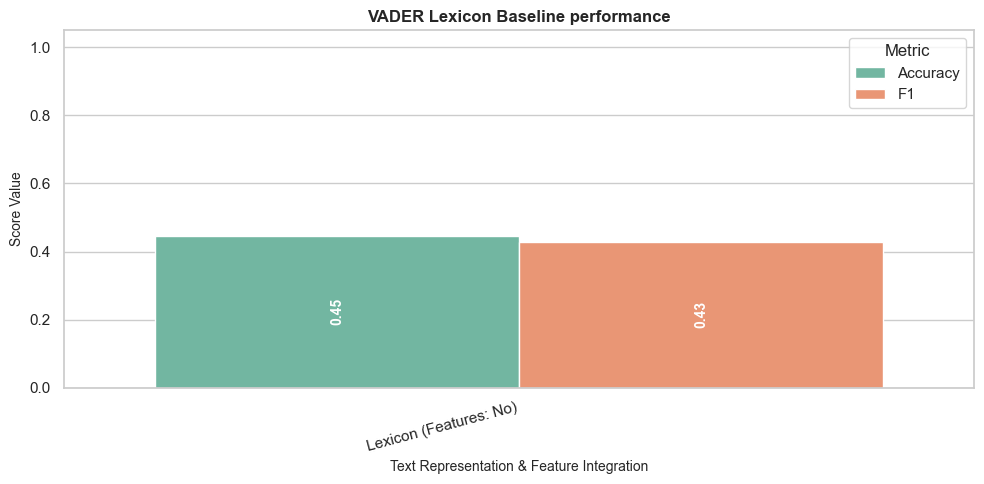

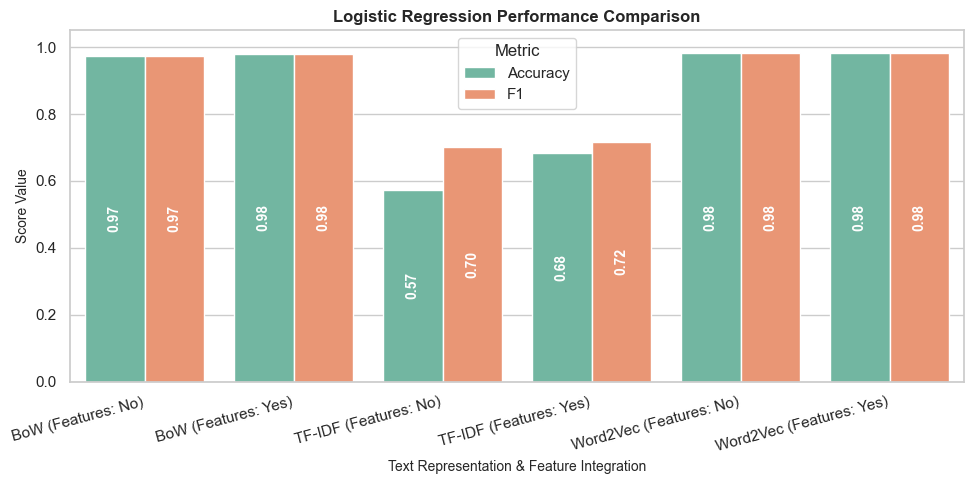

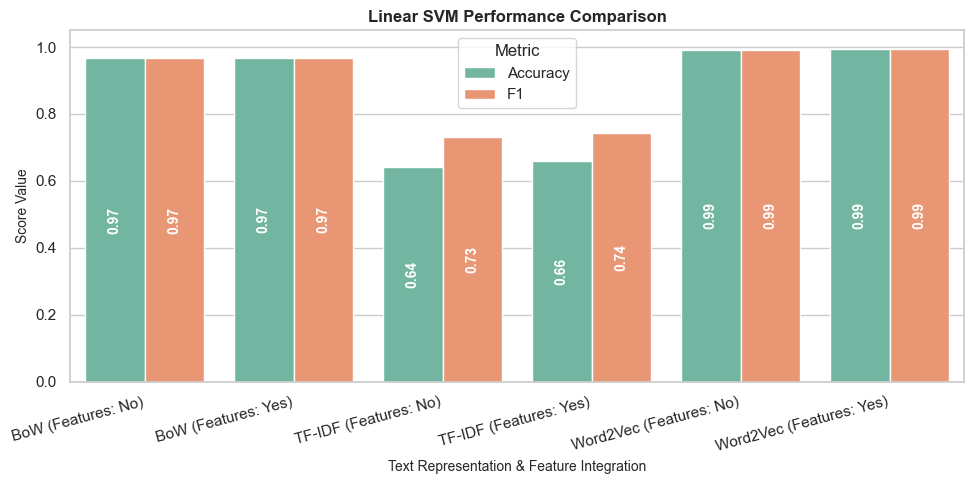

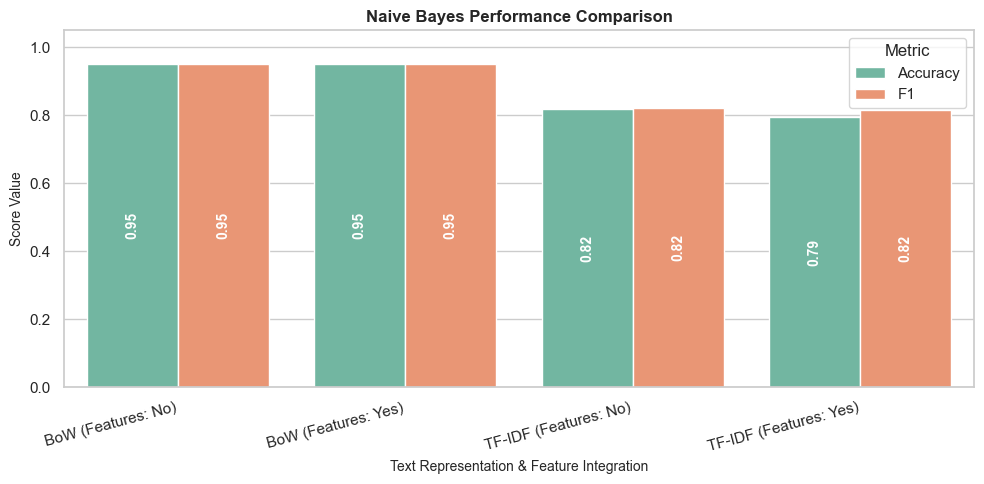

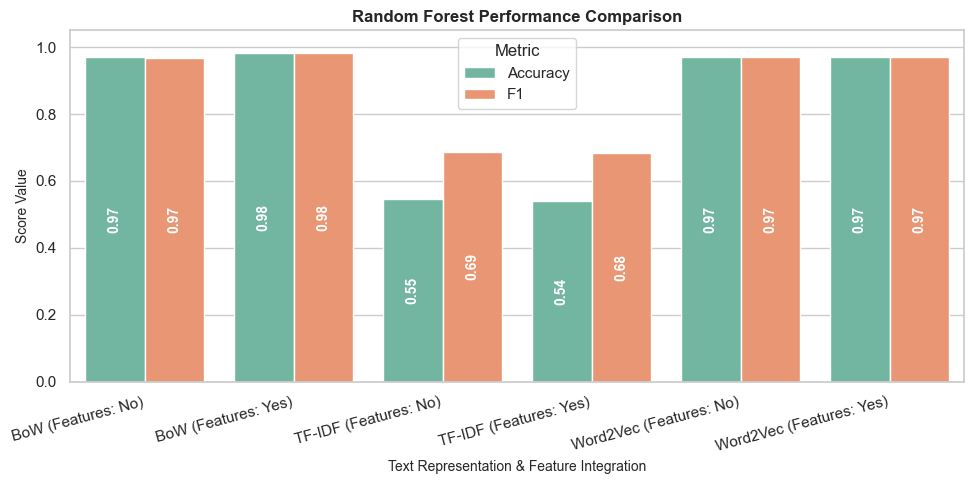

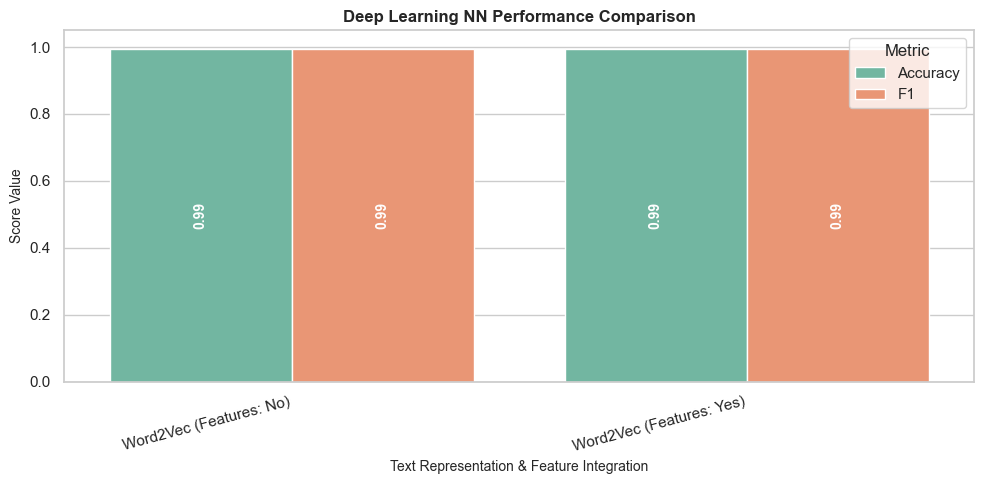

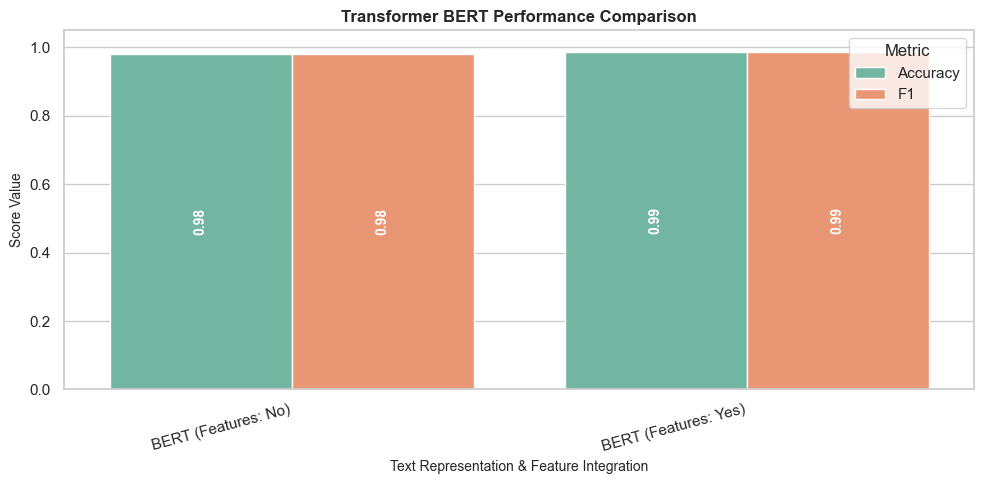


Embedding representation source used: gensim.models.Word2Vec (Trained on Dataset)


In [57]:
def eval_pytorch(model, input_t, feats_t, is_multi=False):
    model.eval()
    with torch.no_grad():
        input_t = input_t.to(device)
        if is_multi:
            feats_t = feats_t.to(device)
            logits = model(input_t, feats_t)
        else:
            logits = model(input_t)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
    return preds

# 0. Rule-based Lexicon baseline
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
threshold = 0.05

# 0. VADER Lexicon baseline
preds_rule = []

for text in test_df['text']:
    scores = sia.polarity_scores(text)
    compound = scores['compound']

    prediction = 1 if compound > threshold else 0
    preds_rule.append(prediction)

preds_rule = np.array(preds_rule)

# Get predictions for all configurations
preds_lr_bow_without = lr_bow_without.predict(X_test_bow_arr)
preds_lr_bow_with = lr_bow_with.predict(X_test_bow_feats)
preds_lr_tfidf_without = lr_without.predict(X_test_tfidf_arr)
preds_lr_tfidf_with = lr_with.predict(X_test_tfidf_feats)
preds_lr_w2v_without = lr_w2v_without.predict(X_test_w2v_avg)
preds_lr_w2v_with = lr_w2v_with.predict(X_test_w2v_feats)

preds_svm_bow_without = svm_bow_without.predict(X_test_bow_arr)
preds_svm_bow_with = svm_bow_with.predict(X_test_bow_feats)
preds_svm_tfidf_without = svm_without.predict(X_test_tfidf_arr)
preds_svm_tfidf_with = svm_with.predict(X_test_tfidf_feats)
preds_svm_w2v_without = svm_w2v_without.predict(X_test_w2v_avg)
preds_svm_w2v_with = svm_w2v_with.predict(X_test_w2v_feats)

preds_nb_bow_without = nb_bow_without.predict(X_test_bow_arr)
preds_nb_bow_with = nb_bow_with.predict(X_test_bow_nb)
preds_nb_tfidf_without = nb_without.predict(X_test_tfidf_arr)
preds_nb_tfidf_with = nb_with.predict(X_test_tfidf_nb)

preds_rf_bow_without = rf_bow_without.predict(X_test_bow_arr)
preds_rf_bow_with = rf_bow_with.predict(X_test_bow_feats)
preds_rf_tfidf_without = rf_without.predict(X_test_tfidf_arr)
preds_rf_tfidf_with = rf_with.predict(X_test_tfidf_feats)
preds_rf_w2v_without = rf_w2v_without.predict(X_test_w2v_avg)
preds_rf_w2v_with = rf_w2v_with.predict(X_test_w2v_feats)

preds_dl_without = eval_pytorch(model_dl_without, test_w2v_t, None, is_multi=False)
preds_dl_with = eval_pytorch(model_dl_with, test_w2v_t, test_feats_t, is_multi=True)

preds_bert_without = eval_pytorch(model_bert_without, test_bert_t, None, is_multi=False)
preds_bert_with = eval_pytorch(model_bert_with, test_bert_t, test_feats_t, is_multi=True)

y_true = test_df['label'].values
all_preds = [
    preds_rule,
    preds_lr_bow_without, preds_lr_bow_with,
    preds_lr_tfidf_without, preds_lr_tfidf_with,
    preds_lr_w2v_without, preds_lr_w2v_with,
    preds_svm_bow_without, preds_svm_bow_with,
    preds_svm_tfidf_without, preds_svm_tfidf_with,
    preds_svm_w2v_without, preds_svm_w2v_with,
    preds_nb_bow_without, preds_nb_bow_with,
    preds_nb_tfidf_without, preds_nb_tfidf_with,
    preds_rf_bow_without, preds_rf_bow_with,
    preds_rf_tfidf_without, preds_rf_tfidf_with,
    preds_rf_w2v_without, preds_rf_w2v_with,
    preds_dl_without, preds_dl_with,
    preds_bert_without, preds_bert_with
]

model_rows = [
    ("VADER", "Lexicon", "No"),
    ("Logistic Regression", "BoW", "No"),
    ("Logistic Regression", "BoW", "Yes"),
    ("Logistic Regression", "TF-IDF", "No"),
    ("Logistic Regression", "TF-IDF", "Yes"),
    ("Logistic Regression", "Word2Vec", "No"),
    ("Logistic Regression", "Word2Vec", "Yes"),
    ("Linear SVM", "BoW", "No"),
    ("Linear SVM", "BoW", "Yes"),
    ("Linear SVM", "TF-IDF", "No"),
    ("Linear SVM", "TF-IDF", "Yes"),
    ("Linear SVM", "Word2Vec", "No"),
    ("Linear SVM", "Word2Vec", "Yes"),
    ("Naive Bayes", "BoW", "No"),
    ("Naive Bayes", "BoW", "Yes"),
    ("Naive Bayes", "TF-IDF", "No"),
    ("Naive Bayes", "TF-IDF", "Yes"),
    ("Random Forest", "BoW", "No"),
    ("Random Forest", "BoW", "Yes"),
    ("Random Forest", "TF-IDF", "No"),
    ("Random Forest", "TF-IDF", "Yes"),
    ("Random Forest", "Word2Vec", "No"),
    ("Random Forest", "Word2Vec", "Yes"),
    ("Deep Learning", "Word2Vec", "No"),
    ("Deep Learning", "Word2Vec", "Yes"),
    ("Transformer", "BERT", "No"),
    ("Transformer", "BERT", "Yes")
]

metrics_list = []
for (model_name, rep_name, eng_feat), preds in zip(model_rows, all_preds):
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average='binary', zero_division=0)
    roc_auc = roc_auc_score(y_true, preds)
    
    # Confusion matrix elements
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    cm_str = f"[{tn} {fp} {fn} {tp}]"
    
    metrics_list.append({
        'Model': model_name,
        'Representation': rep_name,
        'Engineered Features': eng_feat,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm_str
    })

metrics_df = pd.DataFrame(metrics_list)
print("=== Consolidated Academic Performance Comparison Table ===")
display(metrics_df) if 'display' in globals() else print(metrics_df.to_string(index=False))

def plot_family_scores(df_family, title):
    melted = pd.melt(df_family, id_vars=['Representation', 'Engineered Features'],
                      value_vars=['Accuracy', 'F1'],
                      var_name='Metric', value_name='Score')
    melted['Configuration'] = melted['Representation'] + ' (Features: ' + melted['Engineered Features'] + ')'
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=melted, x='Configuration', y='Score', hue='Metric', palette='Set2')
    
    # Render numbers inside each bar
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.2f', 
            label_type='center', 
            color='white', 
            fontsize=10, 
            fontweight='bold',
            rotation=90
        )
        
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Text Representation & Feature Integration', fontsize=10)
    plt.ylabel('Score Value', fontsize=10)
    plt.xticks(rotation=15, ha='right')
    plt.ylim(0.0, 1.05)
    plt.tight_layout()
    plt.show()

print("\nPlotting Performance Scores separate for each Model Family:")
plot_family_scores(metrics_df[metrics_df['Model'] == 'VADER'], 'VADER Lexicon Baseline performance')
plot_family_scores(metrics_df[metrics_df['Model'] == 'Logistic Regression'], 'Logistic Regression Performance Comparison')
plot_family_scores(metrics_df[metrics_df['Model'] == 'Linear SVM'], 'Linear SVM Performance Comparison')
plot_family_scores(metrics_df[metrics_df['Model'] == 'Naive Bayes'], 'Naive Bayes Performance Comparison')
plot_family_scores(metrics_df[metrics_df['Model'] == 'Random Forest'], 'Random Forest Performance Comparison')
plot_family_scores(metrics_df[metrics_df['Model'] == 'Deep Learning'], 'Deep Learning NN Performance Comparison')
plot_family_scores(metrics_df[metrics_df['Model'] == 'Transformer'], 'Transformer BERT Performance Comparison')

print(f"\nEmbedding representation source used: {embedding_source_used}")


=== Top 4 ML Configurations Based on Accuracy ===


,Model,Representation,Engineered Features,Accuracy,Precision,Recall,F1,ROC-AUC
12,Linear SVM,Word2Vec,Yes,0.993333,0.993333,0.993333,0.993333,0.993333
11,Linear SVM,Word2Vec,No,0.992667,0.993324,0.992000,0.992662,0.992667
5,Logistic Regression,Word2Vec,No,0.984000,0.986595,0.981333,0.983957,0.984000
6,Logistic Regression,Word2Vec,Yes,0.983333,0.986577,0.980000,0.983278,0.983333


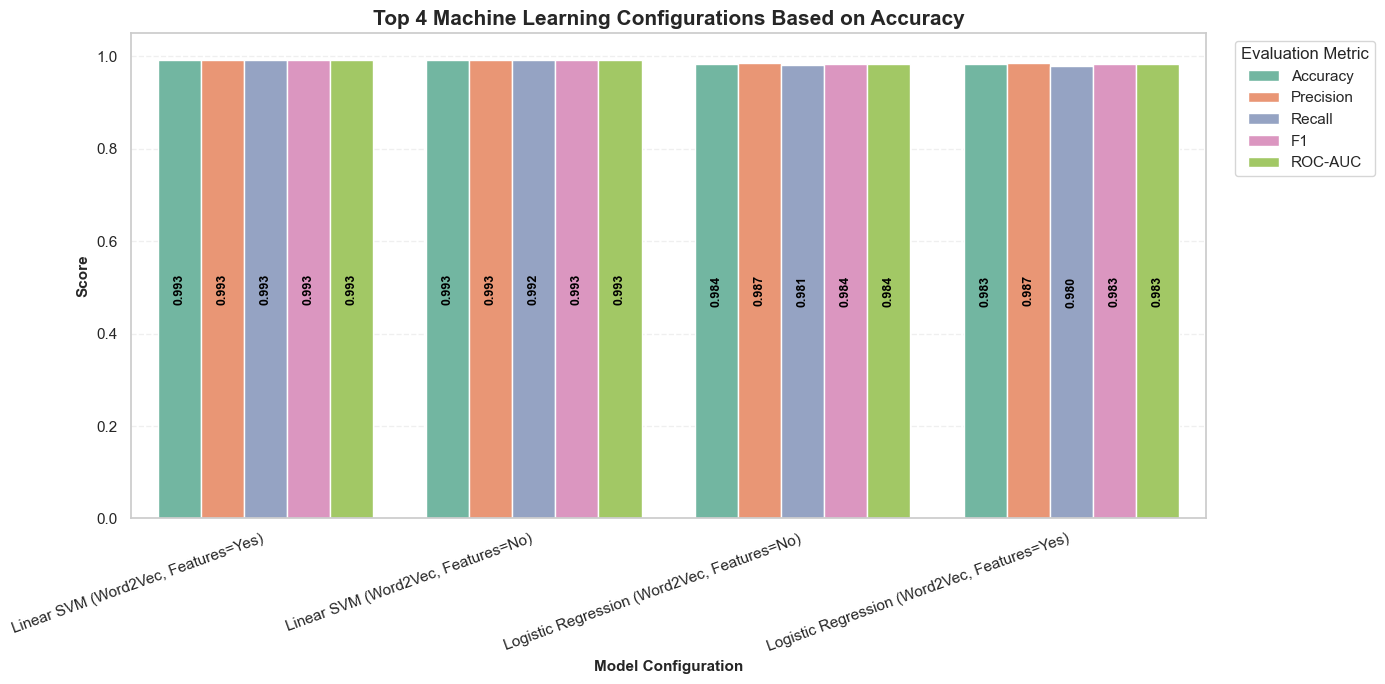

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# TOP 4 ML MODELS BASED ON ACCURACY
# ============================================================

# Exclude Rule-based, Deep Learning and Transformer models
ml_models = metrics_df[
    metrics_df['Model'].isin([
        'Logistic Regression',
        'Linear SVM',
        'Naive Bayes',
        'Random Forest'
    ])
].copy()

# Select top 4 configurations based on Accuracy
top4_ml = (
    ml_models
    .sort_values(by='Accuracy', ascending=False)
    .head(4)
    .copy()
)

# Create readable configuration names
top4_ml['Configuration'] = (
    top4_ml['Model'] + 
    ' (' + 
    top4_ml['Representation'] + 
    ', Features=' + 
    top4_ml['Engineered Features'] + 
    ')'
)

print("=== Top 4 ML Configurations Based on Accuracy ===")
display(
    top4_ml[
        [
            'Model',
            'Representation',
            'Engineered Features',
            'Accuracy',
            'Precision',
            'Recall',
            'F1',
            'ROC-AUC'
        ]
    ]
)

# ============================================================
# PREPARE DATA FOR PLOTTING
# ============================================================

metrics_to_plot = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC'
]

plot_df = top4_ml.melt(
    id_vars=['Configuration'],
    value_vars=metrics_to_plot,
    var_name='Metric',
    value_name='Score'
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=plot_df,
    x='Configuration',
    y='Score',
    hue='Metric',
    palette='Set2'
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        label_type='center',
        color='black',
        fontsize=9,
        fontweight='bold',
        rotation=90
    )

plt.title(
    'Top 4 Machine Learning Configurations Based on Accuracy',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Model Configuration',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Score',
    fontsize=11,
    fontweight='bold'
)

plt.xticks(
    rotation=20,
    ha='right'
)

plt.ylim(0, 1.05)

plt.legend(
    title='Evaluation Metric',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

=== TOP 4 ML CONFIGURATIONS - ROC-AUC ===


,Model,Representation,Engineered Features,Accuracy,ROC-AUC
11,Linear SVM,Word2Vec,No,0.994667,0.994667
12,Linear SVM,Word2Vec,Yes,0.993333,0.993333
5,Logistic Regression,Word2Vec,No,0.992000,0.992000
6,Logistic Regression,Word2Vec,Yes,0.991333,0.991333



Model: Linear SVM (Word2Vec, Features=No)
Accuracy: 0.9947
ROC-AUC: 0.9994


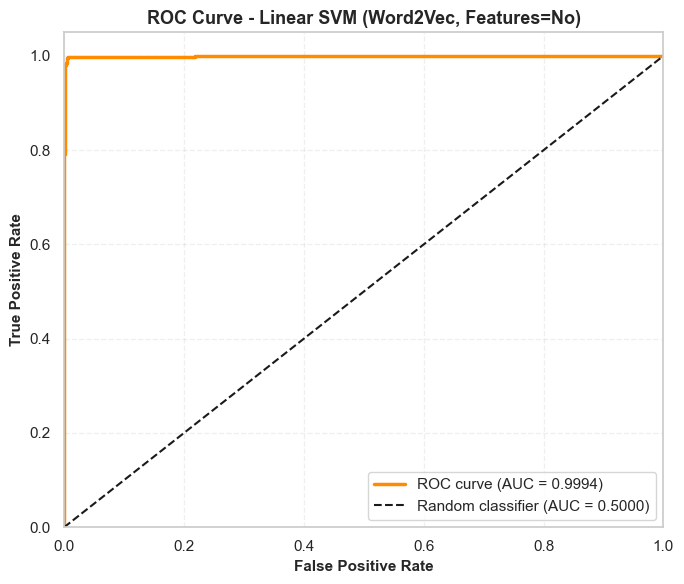


Model: Linear SVM (Word2Vec, Features=Yes)
Accuracy: 0.9933
ROC-AUC: 0.9994


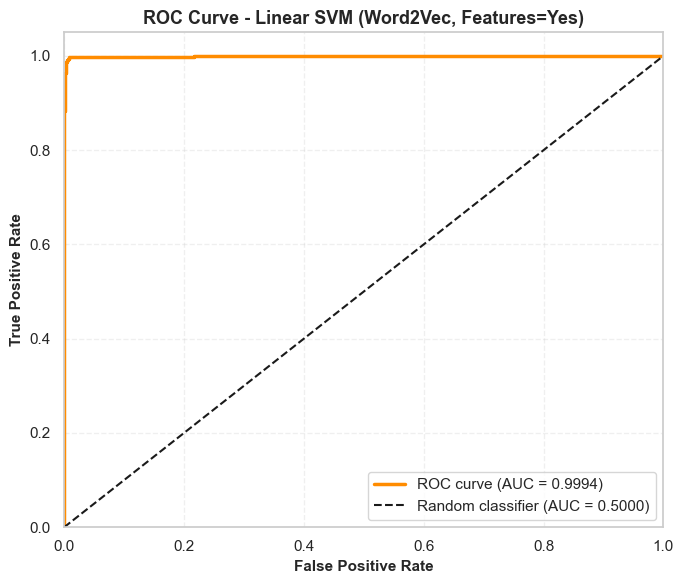


Model: Logistic Regression (Word2Vec, Features=No)
Accuracy: 0.9920
ROC-AUC: 0.9993


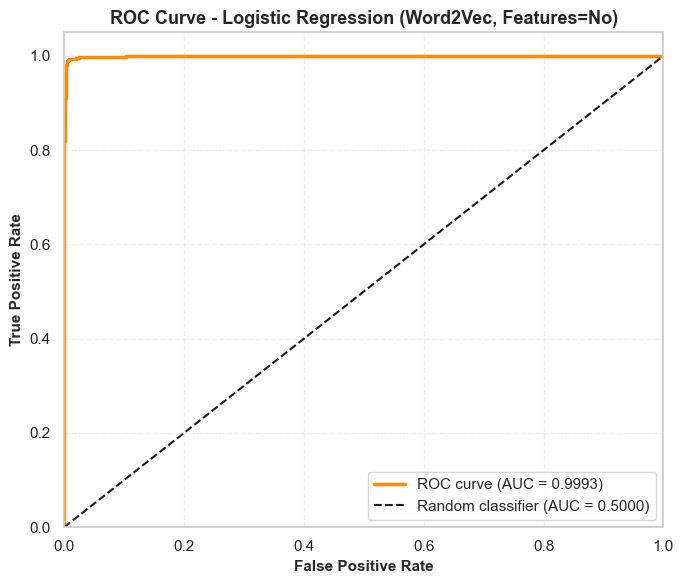


Model: Logistic Regression (Word2Vec, Features=Yes)
Accuracy: 0.9913
ROC-AUC: 0.9994


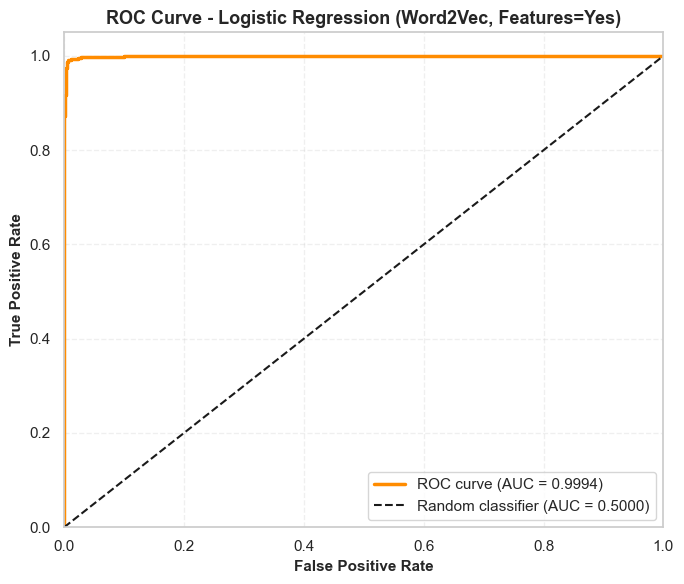

In [9]:
# ============================================================
# ROC CURVES - TOP 4 ML CONFIGURATIONS
# Separate plot for each model
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ------------------------------------------------------------
# SELECT TOP 4 ML CONFIGURATIONS BASED ON ACCURACY
# ------------------------------------------------------------

ml_models = metrics_df[
    metrics_df['Model'].isin([
        'Logistic Regression',
        'Linear SVM',
        'Naive Bayes',
        'Random Forest'
    ])
].copy()

top4_ml = (
    ml_models
    .sort_values(by='Accuracy', ascending=False)
    .head(4)
    .copy()
)

top4_ml['Configuration'] = (
    top4_ml['Model'] +
    ' (' +
    top4_ml['Representation'] +
    ', Features=' +
    top4_ml['Engineered Features'] +
    ')'
)

print("=== TOP 4 ML CONFIGURATIONS - ROC-AUC ===")
display(
    top4_ml[
        [
            'Model',
            'Representation',
            'Engineered Features',
            'Accuracy',
            'ROC-AUC'
        ]
    ]
)

y_test = test_df['label'].values


# ============================================================
# GENERATE SEPARATE ROC PLOT FOR EACH TOP MODEL
# ============================================================

for _, row in top4_ml.iterrows():

    model_name = row['Model']
    representation = row['Representation']
    use_features = str(row['Engineered Features']).lower() in [
        'yes', 'true', '1'
    ]

    # --------------------------------------------------------
    # SELECT TEST DATA
    # --------------------------------------------------------

    if representation == 'BoW':
        X_test = (
            X_test_bow_feats
            if use_features
            else X_test_bow_arr
        )

    elif representation == 'TF-IDF':
        X_test = (
            X_test_tfidf_feats
            if use_features
            else X_test_tfidf_arr
        )

    elif representation == 'Word2Vec':
        X_test = (
            X_test_w2v_feats
            if use_features
            else X_test_w2v_avg
        )

    # --------------------------------------------------------
    # SELECT MODEL AND OBTAIN SCORES
    # --------------------------------------------------------

    if model_name == 'Logistic Regression':

        if representation == 'BoW':
            model = lr_bow_with if use_features else lr_bow_without

        elif representation == 'TF-IDF':
            model = lr_with if use_features else lr_without

        elif representation == 'Word2Vec':
            model = lr_w2v_with if use_features else lr_w2v_without

        scores = model.predict_proba(X_test)[:, 1]

    elif model_name == 'Linear SVM':

        if representation == 'BoW':
            model = svm_bow_with if use_features else svm_bow_without

        elif representation == 'TF-IDF':
            model = svm_with if use_features else svm_without

        elif representation == 'Word2Vec':
            model = svm_w2v_with if use_features else svm_w2v_without

        scores = model.decision_function(X_test)

    elif model_name == 'Naive Bayes':

        if representation == 'BoW':
            model = nb_bow_with if use_features else nb_bow_without

        elif representation == 'TF-IDF':
            model = nb_with if use_features else nb_without

        scores = model.predict_proba(X_test)[:, 1]

    elif model_name == 'Random Forest':

        if representation == 'BoW':
            model = rf_bow_with if use_features else rf_bow_without

        elif representation == 'TF-IDF':
            model = rf_with if use_features else rf_without

        elif representation == 'Word2Vec':
            model = rf_w2v_with if use_features else rf_w2v_without

        scores = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # CALCULATE ROC-AUC
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_score = roc_auc_score(y_test, scores)

    # --------------------------------------------------------
    # PRINT INDIVIDUAL RESULT
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print(f"Model: {row['Configuration']}")
    print(f"Accuracy: {row['Accuracy']:.4f}")
    print(f"ROC-AUC: {auc_score:.4f}")
    print("=" * 65)

    # --------------------------------------------------------
    # SEPARATE ROC PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        color='darkorange',
        linewidth=2.5,
        label=f'ROC curve (AUC = {auc_score:.4f})'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        'k--',
        linewidth=1.5,
        label='Random classifier (AUC = 0.5000)'
    )

    plt.xlabel(
        'False Positive Rate',
        fontsize=11,
        fontweight='bold'
    )

    plt.ylabel(
        'True Positive Rate',
        fontsize=11,
        fontweight='bold'
    )

    plt.title(
        f'ROC Curve - {row["Configuration"]}',
        fontsize=13,
        fontweight='bold'
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1.05)

    plt.grid(
        linestyle='--',
        alpha=0.3
    )

    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

In [64]:
metrics_df

,Model,Representation,Engineered Features,Accuracy,Precision,Recall,F1,ROC-AUC,Confusion Matrix
0,VADER,Lexicon,No,0.445333,0.441761,0.414667,0.427785,0.445333,[357 393 439 311]
1,Logistic Regression,BoW,No,0.974000,0.973369,0.974667,0.974017,0.974000,[730 20 19 731]
2,Logistic Regression,BoW,Yes,0.979333,0.976159,0.982667,0.979402,0.979333,[732 18 13 737]
3,Logistic Regression,TF-IDF,No,0.573333,0.539683,0.997333,0.700375,0.573333,[112 638 2 748]
4,Logistic Regression,TF-IDF,Yes,0.684000,0.649028,0.801333,0.717184,0.684000,[425 325 149 601]
5,Logistic Regression,Word2Vec,No,0.984000,0.986595,0.981333,0.983957,0.984000,[740 10 14 736]
6,Logistic Regression,Word2Vec,Yes,0.983333,0.986577,0.980000,0.983278,0.983333,[740 10 15 735]
7,Linear SVM,BoW,No,0.966667,0.966667,0.966667,0.966667,0.966667,[725 25 25 725]
8,Linear SVM,BoW,Yes,0.968667,0.969292,0.968000,0.968646,0.968667,[727 23 24 726]
9,Linear SVM,TF-IDF,No,0.642000,0.585680,0.970667,0.730557,0.642000,[235 515 22 728]


=== Top 4 Models Based on Accuracy ===


,Model,Representation,Engineered Features,Accuracy,Precision,Recall,F1,ROC-AUC,Confusion Matrix
0,VADER,Lexicon,No,0.445333,0.441761,0.414667,0.427785,0.445333,[357 393 439 311]


C:\Users\tarun\AppData\Local\Temp\ipykernel_7624\4196777395.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rule_based['Configuration'] = (


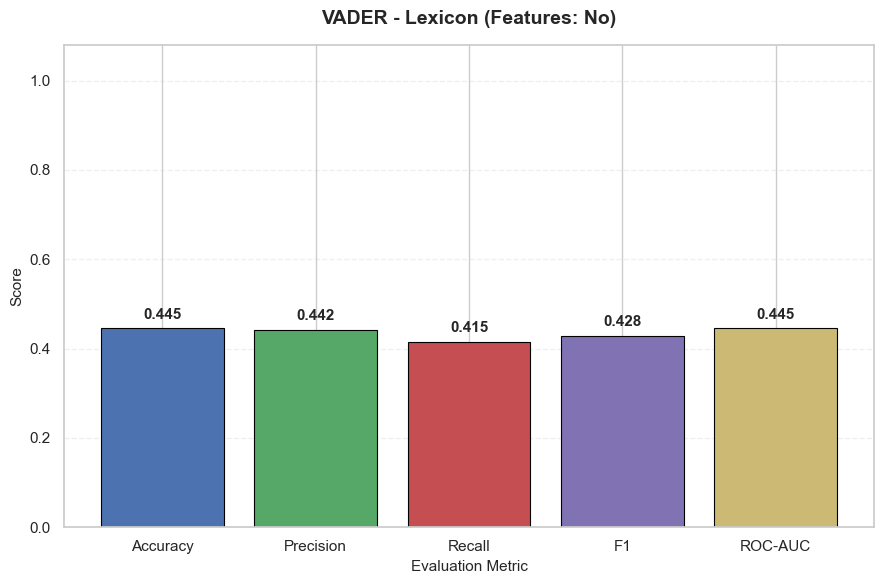

In [ ]:
# =========================================================
# TOP 4 MODELS BASED ON ACCURACY
# =========================================================

rule_based = (
    metrics_df[metrics_df['Model'] == 'VADER']
)

print("=== Top 4 Models Based on Accuracy ===")
display(rule_based)

# Create readable model/configuration names
rule_based['Configuration'] = (
    rule_based['Model'] + ' - ' +
    rule_based['Representation'] +
    ' (Features: ' +
    rule_based['Engineered Features'] + ')'
)

# Metrics to plot
metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC'
]

# Colors for each metric
colors = [
    '#4C72B0',   # Accuracy
    '#55A868',   # Precision
    '#C44E52',   # Recall
    '#8172B3',   # F1
    '#CCB974'    # ROC-AUC
]

# =========================================================
# ONE PLOT FOR EACH MODEL
# =========================================================

for _, row in rule_based.iterrows():

    plt.figure(figsize=(9, 6))

    values = [row[metric] for metric in metric_columns]

    bars = plt.bar(
        metric_columns,
        values,
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )

    # Add metric values on top of bars
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    plt.title(
        row['Configuration'],
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    plt.xlabel(
        'Evaluation Metric',
        fontsize=11
    )

    plt.ylabel(
        'Score',
        fontsize=11
    )

    plt.ylim(0, 1.08)

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

=== Top 4 Models Based on Accuracy ===


,Model,Representation,Engineered Features,Accuracy,Precision,Recall,F1,ROC-AUC,Confusion Matrix
23,Deep Learning,Word2Vec,No,0.994667,0.992042,0.997333,0.994681,0.994667,[744 6 2 748]
12,Linear SVM,Word2Vec,Yes,0.993333,0.993333,0.993333,0.993333,0.993333,[745 5 5 745]
24,Deep Learning,Word2Vec,Yes,0.993333,0.990716,0.996000,0.993351,0.993333,[743 7 3 747]
11,Linear SVM,Word2Vec,No,0.992667,0.993324,0.992000,0.992662,0.992667,[745 5 6 744]


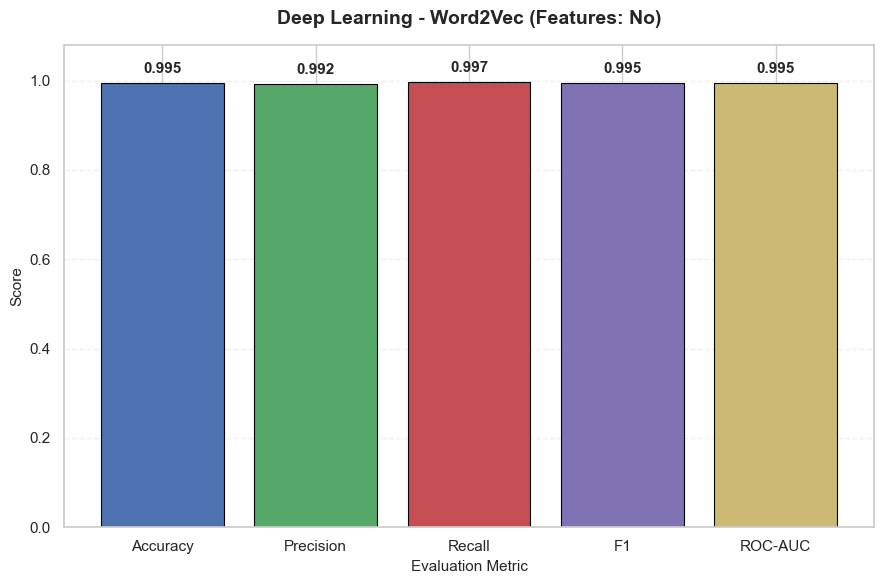

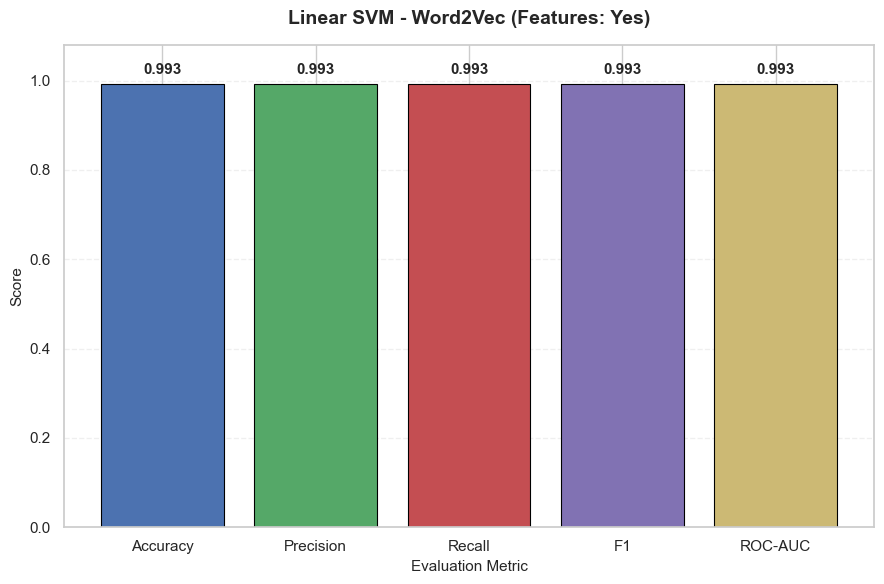

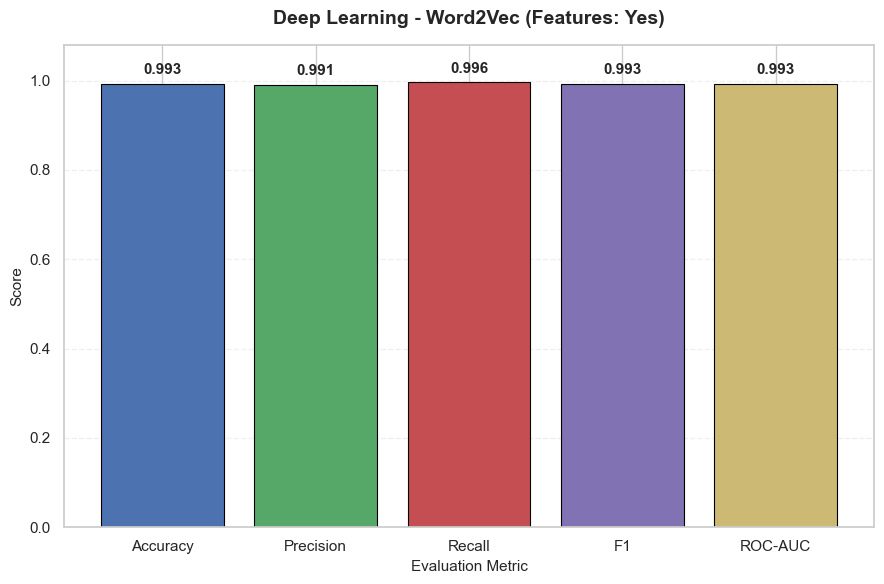

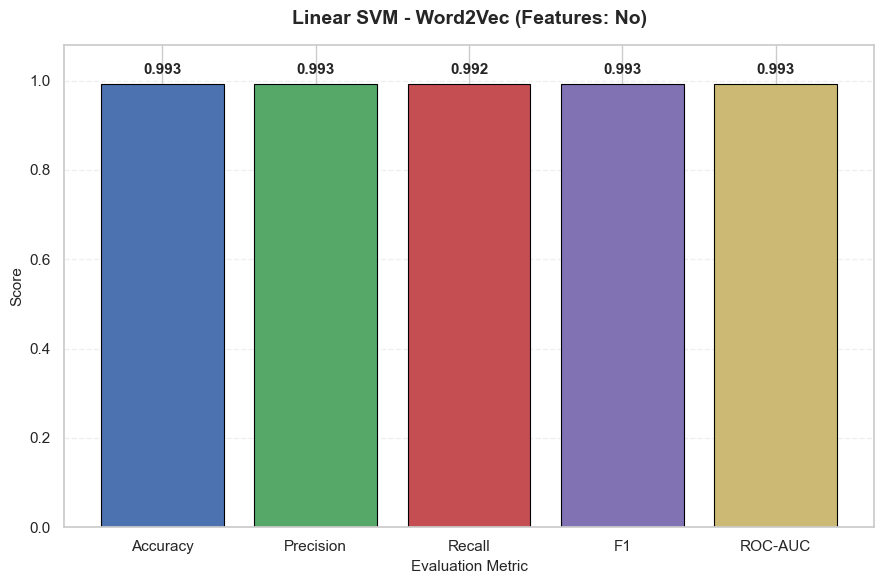

In [61]:
# =========================================================
# TOP 4 MODELS BASED ON ACCURACY
# =========================================================

top4_models = (
    metrics_df
    .sort_values(by='Accuracy', ascending=False)
    .head(4)
    .copy()
)

print("=== Top 4 Models Based on Accuracy ===")
display(top4_models)

# Create readable model/configuration names
top4_models['Configuration'] = (
    top4_models['Model'] + ' - ' +
    top4_models['Representation'] +
    ' (Features: ' +
    top4_models['Engineered Features'] + ')'
)

# Metrics to plot
metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC'
]

# Colors for each metric
colors = [
    '#4C72B0',   # Accuracy
    '#55A868',   # Precision
    '#C44E52',   # Recall
    '#8172B3',   # F1
    '#CCB974'    # ROC-AUC
]

# =========================================================
# ONE PLOT FOR EACH MODEL
# =========================================================

for _, row in top4_models.iterrows():

    plt.figure(figsize=(9, 6))

    values = [row[metric] for metric in metric_columns]

    bars = plt.bar(
        metric_columns,
        values,
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )

    # Add metric values on top of bars
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    plt.title(
        row['Configuration'],
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    plt.xlabel(
        'Evaluation Metric',
        fontsize=11
    )

    plt.ylabel(
        'Score',
        fontsize=11
    )

    plt.ylim(0, 1.08)

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

## 10. Confusion Matrices in 4 Separate Blocks
Finally, we plot the individual Confusion Matrices for all 27 model configurations in **4 separate blocks** (VADER / Rule-based baseline, Classical ML, Deep Learning, and Transformers).


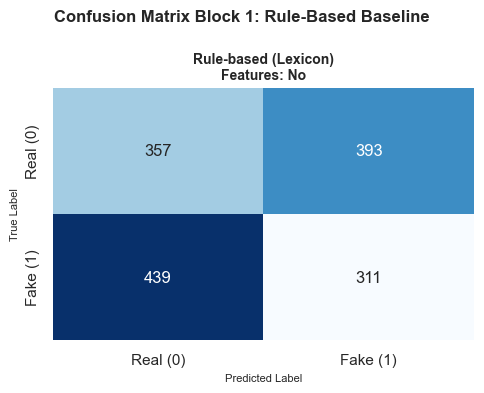

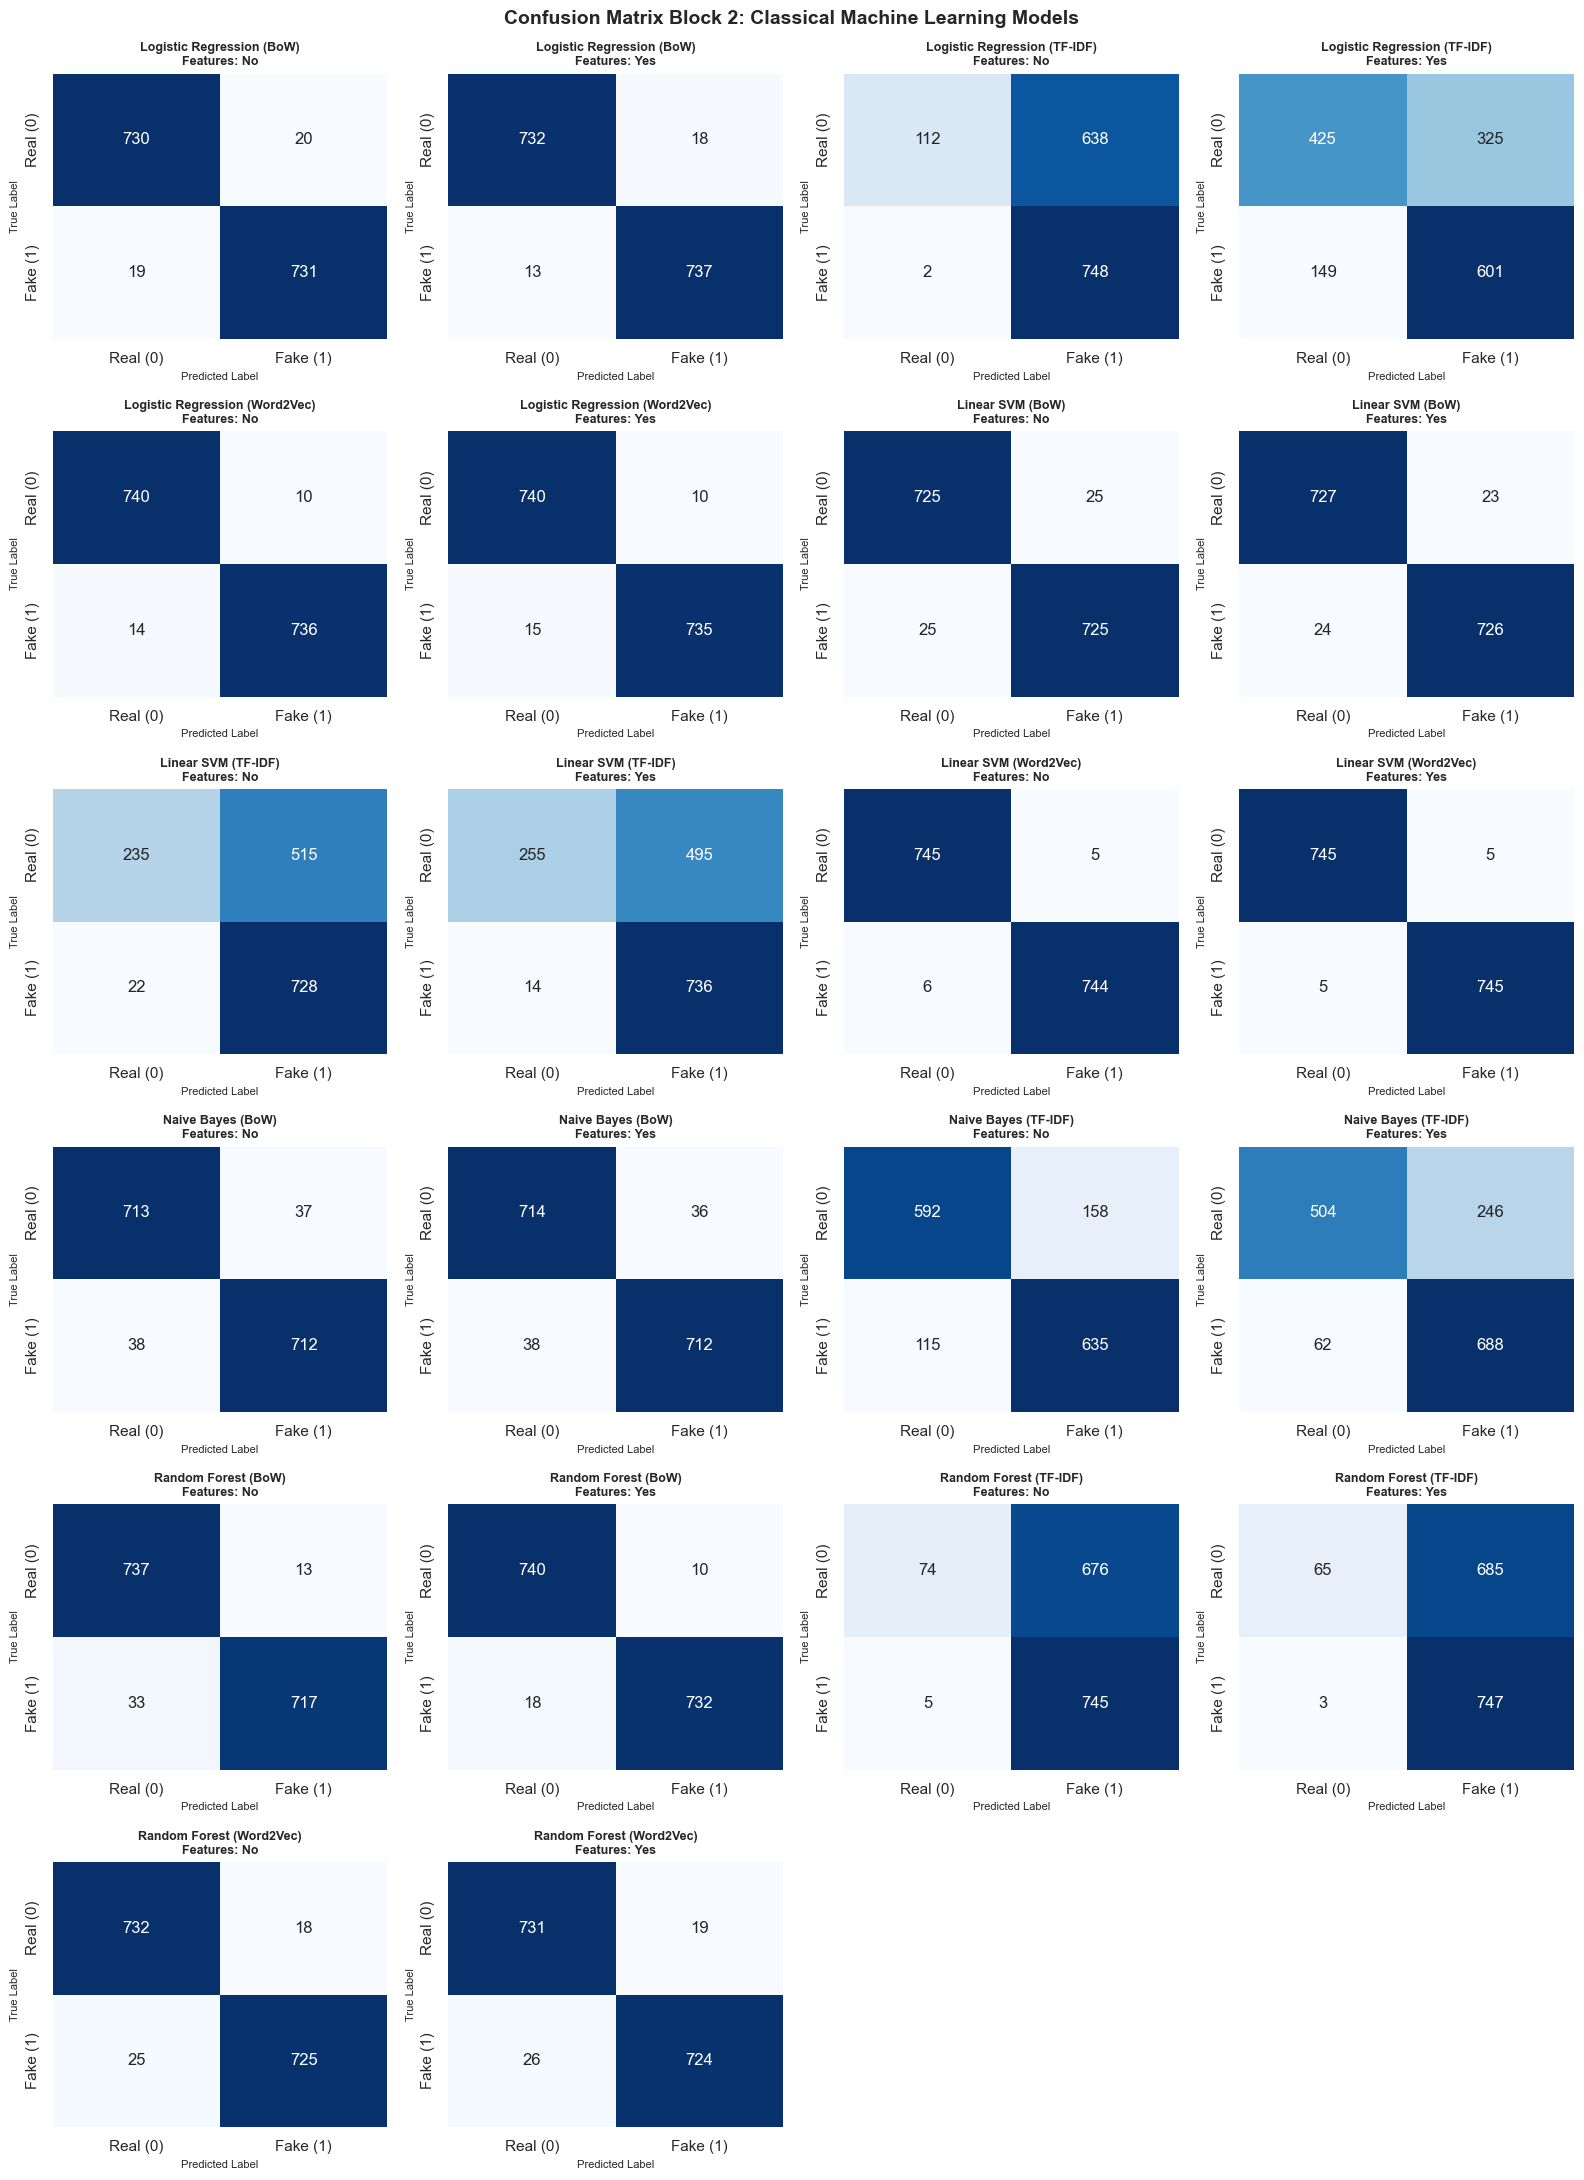

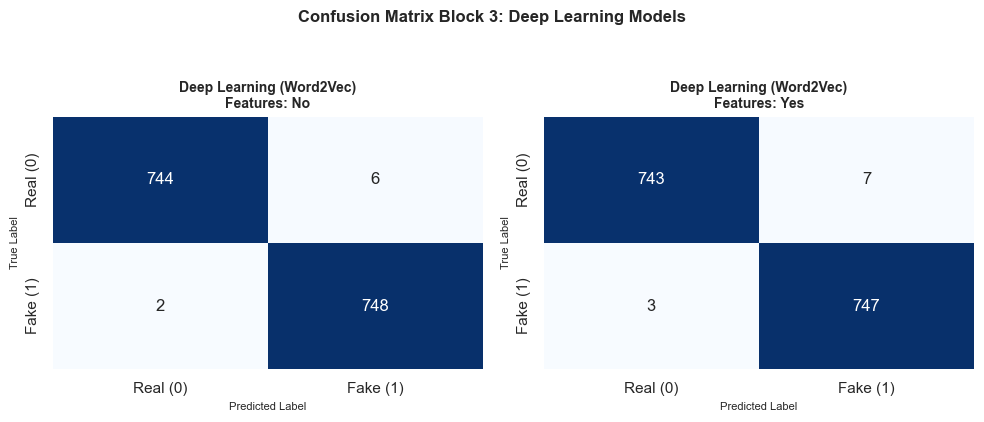

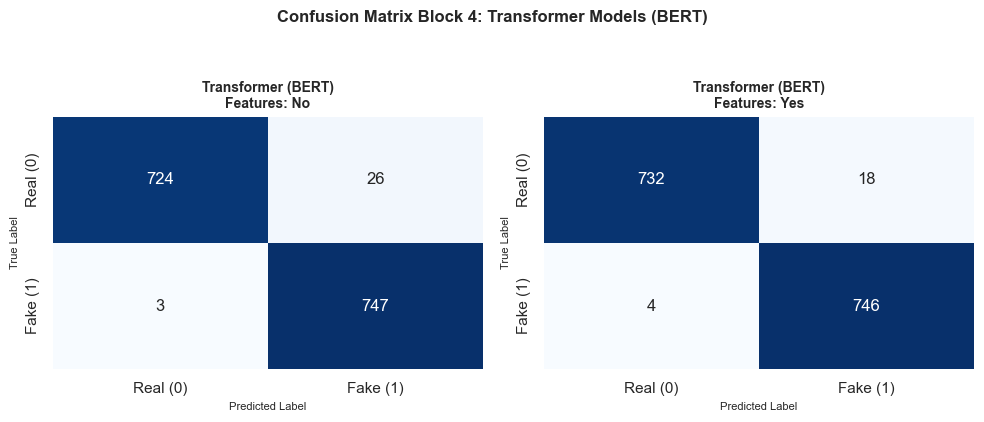

In [65]:
# Extract indices mapping
preds_dict = list(zip(model_rows, all_preds))

# ---------------------------------------------------------
# BLOCK 1: Rule-Based / VADER Baseline
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, preds_rule)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax.set_title("Rule-based (Lexicon)\nFeatures: No", fontsize=10, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=8)
ax.set_ylabel('True Label', fontsize=8)
plt.suptitle('Confusion Matrix Block 1: Rule-Based Baseline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# BLOCK 2: Classical Machine Learning Models
# ---------------------------------------------------------
ml_configs = [x for x in preds_dict if x[0][0] in ('Logistic Regression', 'Linear SVM', 'Naive Bayes', 'Random Forest')]
fig, axes = plt.subplots(6, 4, figsize=(16, 22))
axes = axes.flatten()

for idx, ((model_name, rep_name, eng_feat), preds) in enumerate(ml_configs):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[idx].set_title(f"{model_name} ({rep_name})\nFeatures: {eng_feat}", fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=8)
    axes[idx].set_ylabel('True Label', fontsize=8)

# Hide unused subplots
for idx in range(len(ml_configs), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Confusion Matrix Block 2: Classical Machine Learning Models', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# BLOCK 3: Deep Learning Models
# ---------------------------------------------------------
dl_configs = [x for x in preds_dict if x[0][0] == 'Deep Learning']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, ((model_name, rep_name, eng_feat), preds) in enumerate(dl_configs):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[idx].set_title(f"{model_name} ({rep_name})\nFeatures: {eng_feat}", fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=8)
    axes[idx].set_ylabel('True Label', fontsize=8)

plt.suptitle('Confusion Matrix Block 3: Deep Learning Models', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# BLOCK 4: Transformer Models (BERT)
# ---------------------------------------------------------
tf_configs = [x for x in preds_dict if x[0][0] == 'Transformer']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, ((model_name, rep_name, eng_feat), preds) in enumerate(tf_configs):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[idx].set_title(f"{model_name} ({rep_name})\nFeatures: {eng_feat}", fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=8)
    axes[idx].set_ylabel('True Label', fontsize=8)

plt.suptitle('Confusion Matrix Block 4: Transformer Models (BERT)', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
